# Tarea N°4


<div>
<img src="https://i.ibb.co/v3CvVz9/udd-short.png" width="150"/>
    <br>
    <strong>Universidad del Desarrollo</strong><br>
    <em>Profesor: Fernando Becerra </em><br>

</div>

# Visualización de la Información
## Análisis Exploratorio
*24 de Octubre de 2024*

**Nombre Estudiante(s)**: `Mariangel Arrieta - Ingrid Solís - Giusseppe Lavarello - Rosario Valderrama`

## 1. Objetivo

El objetivo del proyecto es aplicar los conceptos fundamentales y buenas prácticas relativas a la visualización de datos aprendidas durante el curso. Para esto, el proceso consiste en elegir un conjunto de datos, explorarlos y familiarizarse con ellos, elegir la narrativa que se comunicará, definir la(s) representación(es) que mejor comunican el mensaje que se quiere transmitir, y desarrollar una visualización de datos en formato de ensayo visual explicativo en grupos de 3 ó 4 personas

_________________________________________________________________________________________________________________________________________________________________________________

#### "Explorando el mercado de viviendas en la Región Metropolitana: ¿Qué nos dicen los datos?"

En este análisis, nos sumergimos en un conjunto de datos titulado 2023-03-08 Precios Casas RM, cortesía de Kaggle.

La intención es evaluar el panorama dando un vistazo preliminar al conjunto de datos que nos ayude a descifrar patrones y tendencias para construir un ensayo visual y asi entender, en términos claros y atractivos, las variables que están dando forma al mercado inmobiliario en la Región Metropolitana.

In [1]:
# Carga de los Datos
import pandas as pd               #Manejo de datos en Tablas
import numpy as np
import matplotlib.pyplot as plt   #Creación de visualizaciones 
import seaborn as sns             #Creación de visualizaciones  
import missingno as msgn          #Visualizacion de NaNs 
from sklearn.preprocessing import MinMaxScaler #Para Normalizar la data
from sklearn.preprocessing import StandardScaler #Para Estandarizar la data

sns.set_theme() #inicializacion de tematica de seaborn

# Especifica la ruta del archivo
file_path = r'2023-03-08 Precios Casas RM.csv'

# Carga el archivo CSV en un DataFrame
df = pd.read_csv(file_path)

df.columns = df.columns.str.replace(' ', '_') # Normalizar los nombres
df.columns = df.columns.str.lower()

¿Con cuántos registros de viviendas contamos? 

In [2]:
# Viviendas:
valores_unicos_id = df['id'].nunique()
print(f"Exactamente:, {valores_unicos_id}, Cada uno representando un hogar y un precio")

Exactamente:, 7778, Cada uno representando un hogar y un precio


¿Qué comunas están dentro de este panorama? 

In [3]:
# Listado único de comunas
comunas_unicas = df['comuna'].unique()

# Ordenar alfabéticamente para facilitar la revisión
comunas_unicas.sort()

# Mostrar el listado de comunas únicas en formato de lista
print("Listado de comunas únicas:")
for comuna in comunas_unicas:
    print(f"- {comuna}")

Listado de comunas únicas:
- Buin
- CaleradeTango
- Cerrillos
- CerroNavia
- Colina
- Conchalí
- Curacaví
- ElBosque
- ElMonte
- EstaciónCentral
- Huechuraba
- Independencia
- IsladeMaipo
- LaCisterna
- LaFlorida
- LaGranja
- LaPintana
- LaReina
- Lampa
- LasCondes
- LoBarnechea
- LoEspejo
- LoPrado
- Macul
- Maipú
- MaríaPinto
- Melipilla
- PadreHurtado
- Paine
- PedroAguirreCerda
- Peñaflor
- Peñalolén
- Pirque
- Providencia
- Pudahuel
- PuenteAlto
- Quilicura
- QuintaNormal
- Recoleta
- Renca
- SanBernardo
- SanJoaquín
- SanJosédeMaipo
- SanMiguel
- SanPedro
- SanRamón
- Santiago
- Talagante
- Tiltil
- Vitacura
- Ñuñoa


¿Qué información crucial podría faltar? Para ilustrarlo, presentamos el siguiente gráfico, donde las líneas blancas destacan los valores ausentes.

<Axes: >

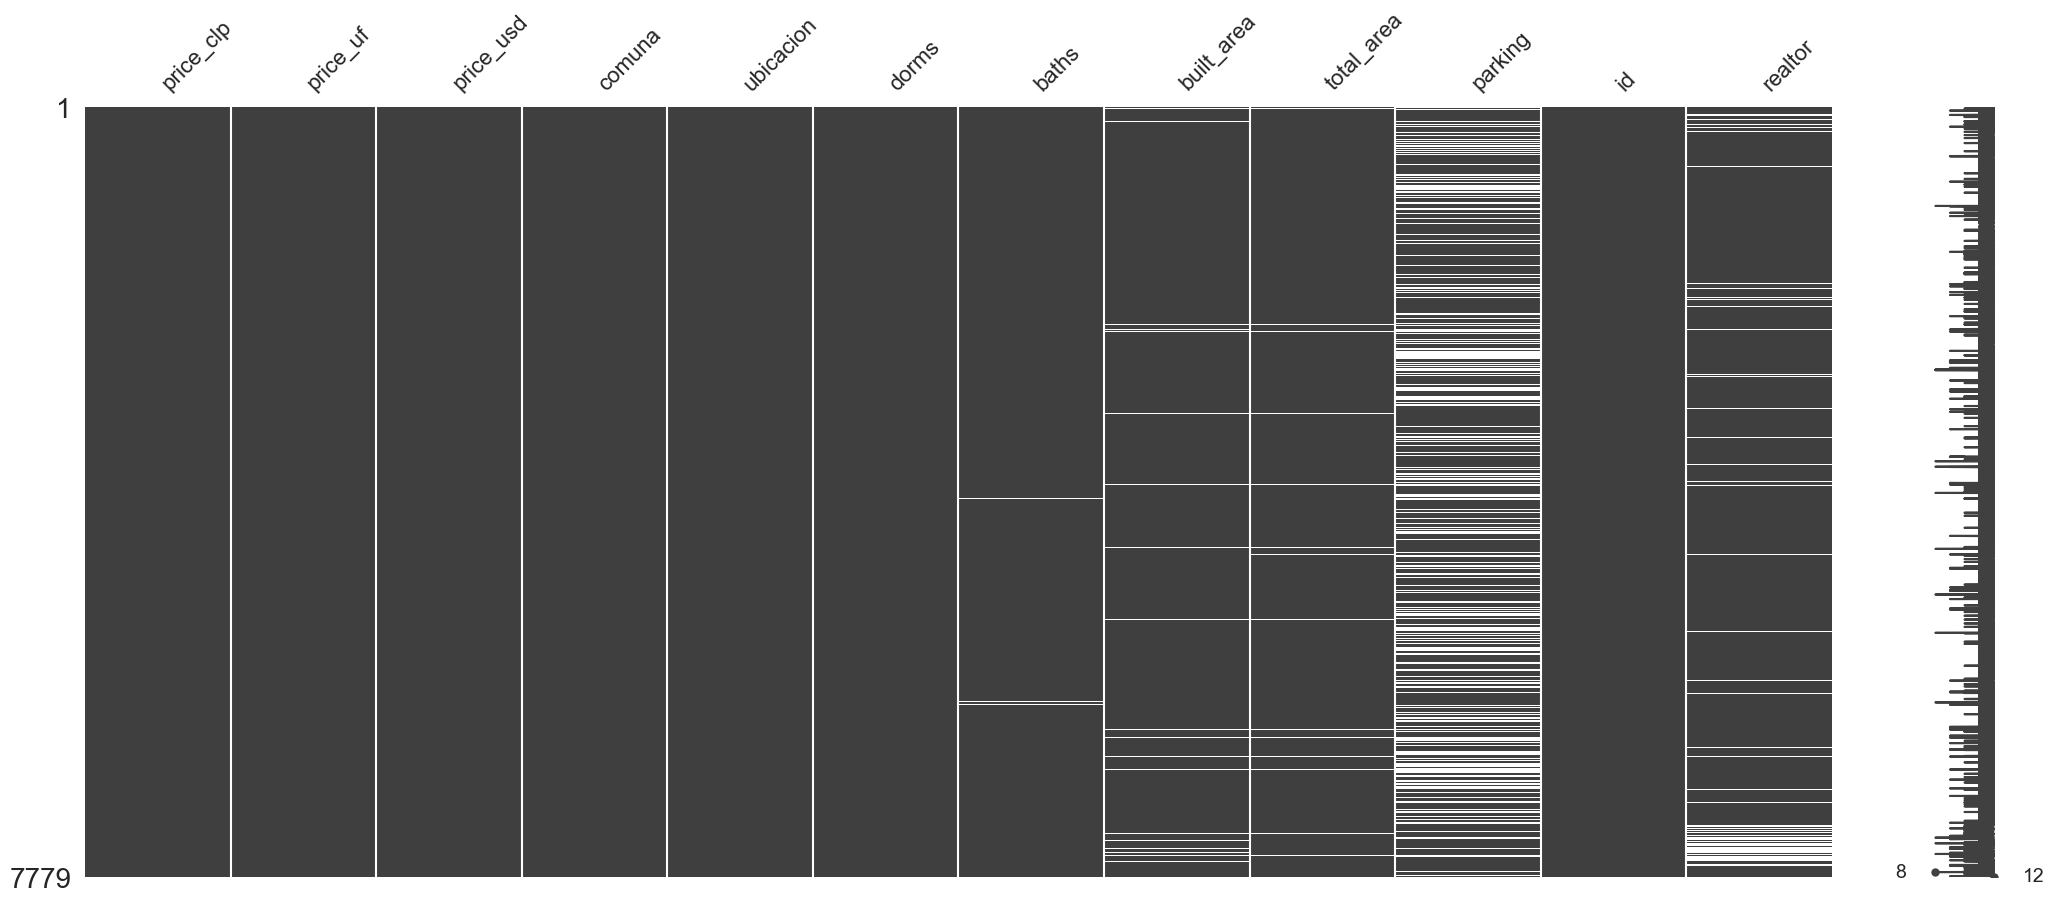

In [4]:
# Valores ausentes
msgn.matrix(df)

#### "Decisiones sobre los datos"

La falta de ciertos valores en el dataset representan un **desafío**, que abordaremos comenzando por los campos con mayores volúmenes de datos ausentes y descendiendo hasta aquellos menos afectados.

En el caso del campo **Parking**, se optó por reemplazar valores NAN con 0. ¿La razón? No se encontraron registros con un valor de 0, lo que sugiere que los NaN indican propiedades sin estacionamiento. Este enfoque asegura que el dataset refleje con precisión la disponibilidad, o no, de estacionamiento, eliminando ambigüedades que podrían haberse originado durante la recolección de datos, posiblemente a través de web scraping.

¿Cuántos valores fueron reemplazados? 

In [6]:
# Mostrar número de NaN en la columna "parking" antes de reemplazarlos
print(f"El número de propiedades sin el dato parking es: {df['parking'].isna().sum()}")

# Reemplazar los NaN de parking por 0
df["parking"].fillna(0, inplace=True)

El número de propiedades sin el dato parking es: 2290


En este análisis, la identidad del realtor —ya sea una inmobiliaria o un agente— no se considera un factor con relación causal directa al objetivo. Dejamos de lado esta variable, enfocándonos en aquellos elementos que realmente aportan pistas sobre el mercado y los precios

In [7]:
# Se descarta la columna Realtor
df.drop("realtor", axis=1, inplace=True)

También es posible identificar NaN en las variables baths, built_area y total_area las cuales si serán determinantes para el análisis posterior. Por lo que se tratan de una manera distinta que se detalla más adelante.

##### - baths: 65 valores NaN 

##### - built_area: 246 valores NaN 

##### - total_area: 208 valores NaN 


In [31]:
# Contar cuántos NaN hay en cada comuna (solo casas únicas que tienen al menos un NaN)
nan_by_comuna = df[df.isna().any(axis=1)].groupby('comuna').size().reset_index(name='casas_con_nan')

# Contar el total de casas por comuna
total_casas_por_comuna = df.groupby('comuna').size().reset_index(name='total_casas')

# Unir los dos resultados en un solo DataFrame
comparacion = pd.merge(total_casas_por_comuna, nan_by_comuna, on='comuna', how='left')

# Reemplazar NaN en 'casas_con_nan' con 0, en caso de que algunas comunas no tengan casas con NaN
comparacion['casas_con_nan'].fillna(0, inplace=True)

# Calcular el porcentaje de casas con valores NaN respecto al total de casas en cada comuna
comparacion['porcentaje_nan'] = (comparacion['casas_con_nan'] / comparacion['total_casas']) * 100

# Mostrar el resultado
print(comparacion)

               comuna  total_casas  casas_con_nan  porcentaje_nan
0                Buin          125            6.0        4.800000
1       CaleradeTango           22            1.0        4.545455
2           Cerrillos           64            4.0        6.250000
3          CerroNavia           53            8.0       15.094340
4              Colina          553           14.0        2.531646
5            Conchalí           48            5.0       10.416667
6            Curacaví           20            3.0       15.000000
7            ElBosque           91            5.0        5.494505
8             ElMonte           17            1.0        5.882353
9     EstaciónCentral          106            3.0        2.830189
10         Huechuraba          122            1.0        0.819672
11      Independencia           70            1.0        1.428571
12        IsladeMaipo           23            1.0        4.347826
13         LaCisterna           85            3.0        3.529412
14        

Es posible verificar que existen algunos valores NaN que tienen un % considerable dentro del total de cada comuna, lo que podrían cambiar los resultados finales del análisis en caso de decidir eliminarlos. Por ejemplo en comunas: Cerro Navia, Conchalí, Curacaví, La Granja, Pirque y San Ramón (sobre 10%). Esto es importante para tomar una decisión sobre todo con respecto a los NaN de **baths**, **built_area** y **total_area**.

En primera instancia, para trabajar los NaN, se busca la mediana para cada casa en cada una de las variables (baths, built_area y total_area), según comuna y según cantidad de dorms.

In [34]:
# Calcular la mediana por comuna y número de dormitorios para 'baths', 'built_area', y 'total_area'
medianas_por_comuna_dorms = df.groupby(['comuna', 'dorms'])[['baths', 'built_area', 'total_area']].median().reset_index()

# Mostrar la tabla con las medianas por comuna y número de dormitorios
print(medianas_por_comuna_dorms)

    comuna  dorms  baths  built_area  total_area
0     Buin      2    1.0        54.0        98.0
1     Buin      3    2.0        83.0       167.0
2     Buin      4    3.0       125.0       220.0
3     Buin      5    3.0       138.0       161.5
4     Buin      6    4.0       330.0      5000.0
..     ...    ...    ...         ...         ...
397  Ñuñoa      7    5.0       300.0       400.0
398  Ñuñoa      8    4.0       250.0       375.0
399  Ñuñoa     10    3.0       305.0       562.5
400  Ñuñoa     11    4.5       417.5       591.0
401  Ñuñoa     12    4.0       450.0       490.0

[402 rows x 5 columns]


In [35]:
# Reemplazar los valores NaN en el DataFrame original según la mediana de cada comuna y cantidad de dorms
for i, row in medianas_por_comuna_dorms.iterrows():
    # Crear la máscara para seleccionar las filas con NaN en 'baths', 'built_area', 'total_area' en la comuna y dorms específicos
    mask = (df['comuna'] == row['comuna']) & (df['dorms'] == row['dorms'])
    
    # Reemplazar NaN en 'baths'
    df.loc[mask & df['baths'].isna(), 'baths'] = row['baths']
    
    # Reemplazar NaN en 'built_area'
    df.loc[mask & df['built_area'].isna(), 'built_area'] = row['built_area']
    
    # Reemplazar NaN en 'total_area'
    df.loc[mask & df['total_area'].isna(), 'total_area'] = row['total_area']

# Verificar que los valores NaN hayan sido reemplazados
print(df[['baths', 'built_area', 'total_area']].isna().sum())

baths         5
built_area    1
total_area    1
dtype: int64


In [36]:
# Eliminar las filas donde hay valores NaN en 'baths', 'built_area', o 'total_area'
df_sin_nan = df.dropna(subset=['baths', 'built_area', 'total_area'])

# Verificar que ya no hay valores NaN en las columnas mencionadas
print(df_sin_nan[['baths', 'built_area', 'total_area']].isna().sum())

baths         0
built_area    0
total_area    0
dtype: int64


In [37]:
df_sin_nan.loc[:, 'baths'] = df_sin_nan['baths'].fillna(0)
df_sin_nan.loc[:, 'baths'] = df_sin_nan['baths'].astype(int)

df_sin_nan.head(2)

,price_clp,price_uf,price_usd,comuna,ubicacion,dorms,baths,built_area,total_area,parking,id
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299


Los valores NaN restantes se eliminan, ya que la proporción es relativamente pequeña en comparación con el tamaño total del dataset (menos del 3%). Se considera que la eliminación de estos nulos tendrá un impacto limitado en la precisión y generalización del modelo.


In [39]:
# Guardar el DataFrame sin valores NaN en un nuevo DataFrame
df_nuevo_sin_nan = df_sin_nan.copy()

# Verificar que el nuevo DataFrame ha sido creado
print(f"El nuevo DataFrame tiene {df_nuevo_sin_nan.shape[0]} filas y {df_nuevo_sin_nan.shape[1]} columnas.")

# Si deseas guardarlo en un archivo Excel para futuras referencias
ruta_guardado = r'..\data\Precios_Casas_RM_sin_NaN.xlsx'
df_nuevo_sin_nan.to_excel(ruta_guardado, index=False)

print(f"Archivo guardado en: {ruta_guardado}")

El nuevo DataFrame tiene 7772 filas y 11 columnas.
Archivo guardado en: ..\data\Precios_Casas_RM_sin_NaN.xlsx


In [40]:
df_nuevo_sin_nan.isna().sum()/df_nuevo_sin_nan.shape[0]*100 # Se calcula el % de los datos que quedan nulos

price_clp     0.0
price_uf      0.0
price_usd     0.0
comuna        0.0
ubicacion     0.0
dorms         0.0
baths         0.0
built_area    0.0
total_area    0.0
parking       0.0
id            0.0
dtype: float64

### 3.3. Limpieza de datos

In [42]:
# Cargar el archivo Excel proporcionado
ruta_archivo_excel = r'..\data\Precios_Casas_RM_sin_NaN.xlsx'
df_nuevo = pd.read_excel(ruta_archivo_excel)

# Mostrar las primeras filas del DataFrame para verificar que el archivo se ha cargado correctamente
df_nuevo.head()

,price_clp,price_uf,price_usd,comuna,ubicacion,dorms,baths,built_area,total_area,parking,id
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4,384.0,732.0,3,11700213
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1,112.0,145.0,1,10894299
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1,59.0,243.0,2,10257635
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1,103.0,73.0,1,9232092
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1,57.0,67.0,1,7085397


In [43]:
df_nuevo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price_clp   7772 non-null   int64  
 1   price_uf    7772 non-null   int64  
 2   price_usd   7772 non-null   int64  
 3   comuna      7772 non-null   object 
 4   ubicacion   7772 non-null   object 
 5   dorms       7772 non-null   int64  
 6   baths       7772 non-null   int64  
 7   built_area  7772 non-null   float64
 8   total_area  7772 non-null   float64
 9   parking     7772 non-null   int64  
 10  id          7772 non-null   int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 668.0+ KB


Es posible ver que el nuevo dataset cuenta con 7772 filas y 11 columnas. Ninguna de las variables tiene valores NaN, sin embargo, aún pudieran haber outliers importantes que revisar.

Se decide quedar solo con variable precio price_uf y se eliminan las variables *"ubicación"* y *"id"* dado a que no son determinantes en este análisis.

In [46]:
df_nuevo = df_nuevo.drop(columns=['price_clp', 'price_usd', 'ubicacion','id'])
df_nuevo.head(5)

,price_uf,comuna,dorms,baths,built_area,total_area,parking
0,11500,QuintaNormal,7,4,384.0,732.0,3
1,2950,PedroAguirreCerda,2,1,112.0,145.0,1
2,3600,EstaciónCentral,3,1,59.0,243.0,2
3,2107,Colina,3,1,103.0,73.0,1
4,1489,Colina,2,1,57.0,67.0,1


Para la revisión de outliers aplicamos un boxplot para cada variable determinante.

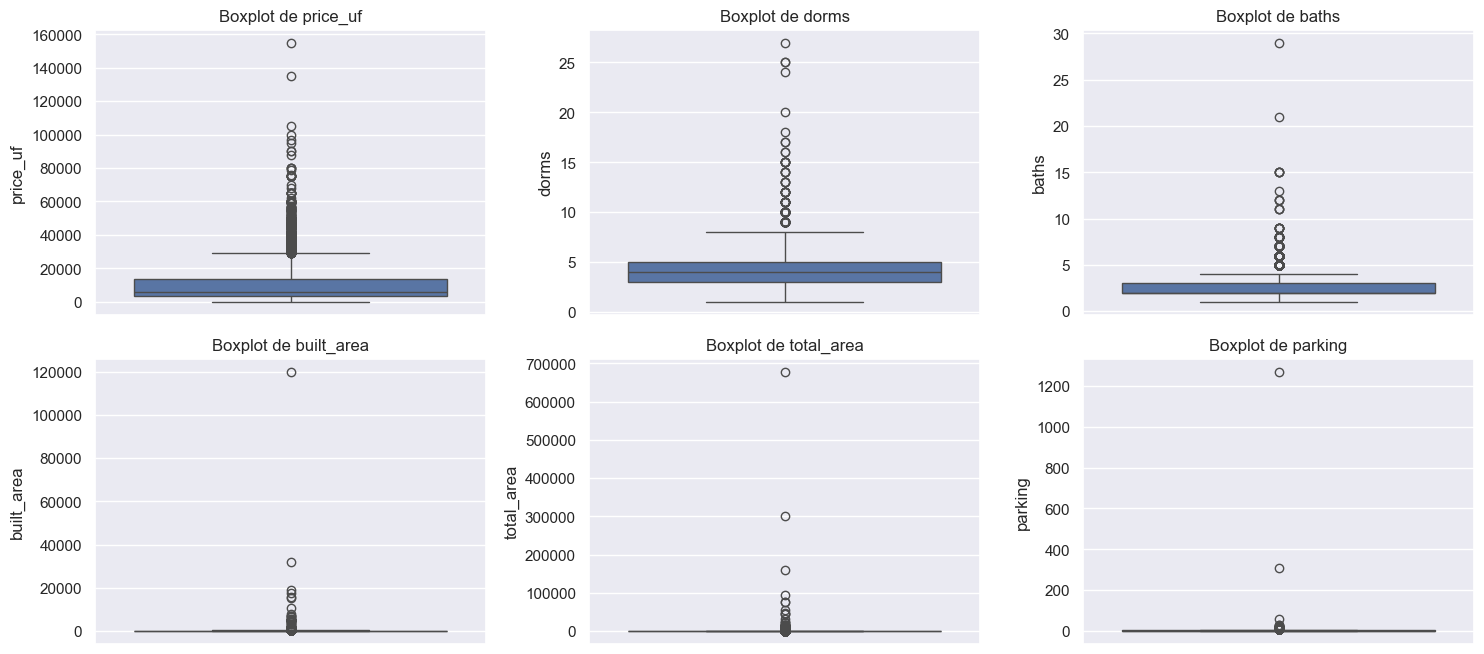

In [48]:
columnas_numericas = df_nuevo.select_dtypes(include='number')

plt.figure(figsize=(15, 10))  # Ajustar el tamaño de la figura
for i, column in enumerate(columnas_numericas.columns, 1):
    plt.subplot(3, 3, i)  # Crear subplots para cada boxplot (ajustar según el número de columnas)
    sns.boxplot(data=df_nuevo[column])
    plt.title(f'Boxplot de {column}')
    plt.tight_layout()

# Mostrar el gráfico
plt.show()

# for count, column in enumerate(df1.select_dtypes(include='number').columns):
#     sns.boxplot(x=df1[column],ax=ax[i])
#     plt.title(f'Boxplot de {column}')
#     plt.show()


In [49]:
# Bucle para recorrer cada columna numérica y detectar y contar valores atípicos
out_cols=df_nuevo.select_dtypes(include='number').columns
lims = {}
for column in out_cols:
    print(f"Procesando columna: {column}")
    
    # Calcular el valor del percentil 25
    percentil25 = df_nuevo[column].quantile(0.25)
    
    # Calcular el valor del percentil 75
    percentil75 = df_nuevo[column].quantile(0.75)
    
    # Calcular el rango intercuartil (IQR)
    iqr = percentil75 - percentil25
    
    # Definir los límites superior e inferior para los valores no atípicos
    limite_superior = percentil75 + 1.5 * iqr
    limite_inferior = percentil25 - 1.5 * iqr
    limite_inferior = limite_inferior if limite_inferior > 0 else 0
    lims[column] = [limite_superior,limite_inferior]
    
    print(f"Límite inferior para {column}:", limite_inferior)
    print(f"Límite superior para {column}:", limite_superior)
    
    # Identificar los valores atípicos en la columna actual
    valores_atípicos = df_nuevo[(df_nuevo[column] > limite_superior) | (df_nuevo[column] < limite_inferior)]
    
    # Contar el número de filas con valores atípicos
    print(f"Número de filas que contienen valores atípicos en {column}: {len(valores_atípicos)}\n")

Procesando columna: price_uf
Límite inferior para price_uf: 0
Límite superior para price_uf: 29442.0
Número de filas que contienen valores atípicos en price_uf: 464

Procesando columna: dorms
Límite inferior para dorms: 0
Límite superior para dorms: 8.0
Número de filas que contienen valores atípicos en dorms: 119

Procesando columna: baths
Límite inferior para baths: 0.5
Límite superior para baths: 4.5
Número de filas que contienen valores atípicos en baths: 731

Procesando columna: built_area
Límite inferior para built_area: 0
Límite superior para built_area: 372.5
Número de filas que contienen valores atípicos en built_area: 574

Procesando columna: total_area
Límite inferior para total_area: 0
Límite superior para total_area: 889.625
Número de filas que contienen valores atípicos en total_area: 907

Procesando columna: parking
Límite inferior para parking: 0
Límite superior para parking: 7.5
Número de filas que contienen valores atípicos en parking: 228



Para tratar los outliers se aplica un bucle que recorre cada columna numérica del DataFrame df1 con el objetivo de detectar y contar valores atípicos en cada una de ellas. Para cada columna, primero calcula los percentiles 25 y 75, con lo cual obtiene el rango intercuartil (IQR). A partir de este rango, se definen los límites superior e inferior, que sirven como umbrales para identificar valores atípicos. Estos límites se calculan como 1.5 veces el IQR por encima del percentil 75 (límite superior) y por debajo del percentil 25 (límite inferior), ajustando el límite inferior a cero si el resultado es negativo. Posteriormente, el código identifica y cuenta cuántos valores en la columna están por encima o por debajo de estos límites, mostrando dicha información para cada columna. Además, almacena los límites superior e inferior para cada variable en un diccionario llamado lims.

In [51]:
# Usar una máscara booleana para eliminar valores atípicos
mask = True
for column, lim in lims.items():
    mask &= ((df_nuevo[column] <= lim[0]) & (df_nuevo[column] >= lim[1]))
df2 = df_nuevo[mask].copy()

In [52]:

# Asegurarse de que las columnas sean del tipo float64
#df2['price_uf'] = df2['price_uf'].astype(float)
#df2['dorms'] = df2['dorms'].astype(float)
#df2['baths'] = df2['baths'].astype(float)
#df2['built_area'] = df2['built_area'].astype(float)
#df2['total_area'] = df2['total_area'].astype(float)

# Bucle para recorrer cada columna numérica y detectar y contar valores atípicos
#out_cols = df_nuevo.select_dtypes(include='number').columns
#lims = {}

#for column in out_cols:
#    print(f"Procesando columna: {column}")
    
    # Calcular el valor del percentil 25 y 75
#    percentil25 = df_nuevo[column].quantile(0.25)
#    percentil75 = df_nuevo[column].quantile(0.75)
    
    # Calcular el rango intercuartil (IQR)
#    iqr = percentil75 - percentil25
    
    # Definir los límites superior e inferior para los valores no atípicos
#    limite_superior = percentil75 + 1.5 * iqr
#    limite_inferior = percentil25 - 1.5 * iqr
#    limite_inferior = limite_inferior if limite_inferior > 0 else 0
#    lims[column] = [limite_superior, limite_inferior]
    
    # Identificar los valores atípicos
#    valores_atipicos = df_nuevo[(df_nuevo[column] > limite_superior) | (df_nuevo[column] < limite_inferior)]
    
#    if len(valores_atipicos) > 0:
        # Reemplazo de los valores atípicos según la columna
#        if column == 'dorms':
#            mediana_baths = df_nuevo.groupby('comuna')['baths'].transform('median').astype(float)
#            print(f"Reemplazando valores atípicos en 'dorms' por la mediana de 'baths': {mediana_baths.unique()}")
#            df_nuevo.loc[(df_nuevo[column] > limite_superior) | (df_nuevo[column] < (limite_inferior+1)), 'dorms'] = mediana_baths
        
#        elif column == 'price_uf':
#            mediana_built_area = df_nuevo.groupby('comuna')['built_area'].transform('median').astype(float)
#            print(f"Reemplazando valores atípicos en 'price_uf' por la mediana de 'built_area': {mediana_built_area.unique()}")
#            df_nuevo.loc[(df_nuevo[column] > limite_superior) | (df_nuevo[column] < (limite_inferior+100)), 'price_uf'] = mediana_built_area
        
#        elif column == 'baths':
#            mediana_dorms = df_nuevo.groupby('comuna')['dorms'].transform('median').astype(float)
#            print(f"Reemplazando valores atípicos en 'baths' por la mediana de 'dorms': {mediana_dorms.unique()}")
#            df_nuevo.loc[(df_nuevo[column] > limite_superior) | (df_nuevo[column] < limite_inferior), 'baths'] = mediana_dorms
        
#        elif column == 'built_area':
#            mediana_dorms_baths = df_nuevo.groupby('comuna')[['dorms', 'baths']].median().mean(axis=1).astype(float)
#            print(f"Reemplazando valores atípicos en 'built_area' por la mediana de 'dorms y baths': {mediana_dorms_baths.unique()}")
#            df_nuevo['mediana_dorms_baths'] = df_nuevo['comuna'].map(mediana_dorms_baths)
#            df_nuevo.loc[(df_nuevo[column] > limite_superior) | (df_nuevo[column] < (limite_inferior+20)), 'built_area'] = df_nuevo['mediana_dorms_baths']
        
#        elif column == 'total_area':
#            mediana_dorms_baths = df_nuevo.groupby('comuna')[['dorms', 'baths']].median().mean(axis=1).astype(float)
#            print(f"Reemplazando valores atípicos en 'total_area' por la mediana de 'dorms y baths': {mediana_dorms_baths.unique()}")
#            df_nuevo['mediana_dorms_baths'] = df_nuevo['comuna'].map(mediana_dorms_baths)
#            df_nuevo.loc[(df_nuevo[column] > limite_superior) | (df_nuevo[column] < (limite_inferior+30)), 'total_area'] = df_nuevo['mediana_dorms_baths']

        # Eliminar columna temporal si fue creada
#        if 'mediana_dorms_baths' in df_nuevo.columns:
#            df_nuevo.drop(columns=['mediana_dorms_baths'], inplace=True)

    # Recalcular los límites tras el reemplazo de valores atípicos
#    percentil25 = df_nuevo[column].quantile(0.25)
#    percentil75 = df_nuevo[column].quantile(0.75)
#    iqr = percentil75 - percentil25
#    limite_superior = percentil75 + 1.5 * iqr
#    limite_inferior = percentil25 - 1.5 * iqr
#    limite_inferior = limite_inferior if limite_inferior > 0 else 0
#    lims[column] = [limite_superior, limite_inferior]

#    print(f"Número de filas que contienen valores atípicos en {column} después del reemplazo: {len(valores_atipicos)}\n")


In [53]:
df2.head()

,price_uf,comuna,dorms,baths,built_area,total_area,parking
1,2950,PedroAguirreCerda,2,1,112.0,145.0,1
2,3600,EstaciónCentral,3,1,59.0,243.0,2
3,2107,Colina,3,1,103.0,73.0,1
4,1489,Colina,2,1,57.0,67.0,1
5,2641,EstaciónCentral,2,1,72.0,131.0,0


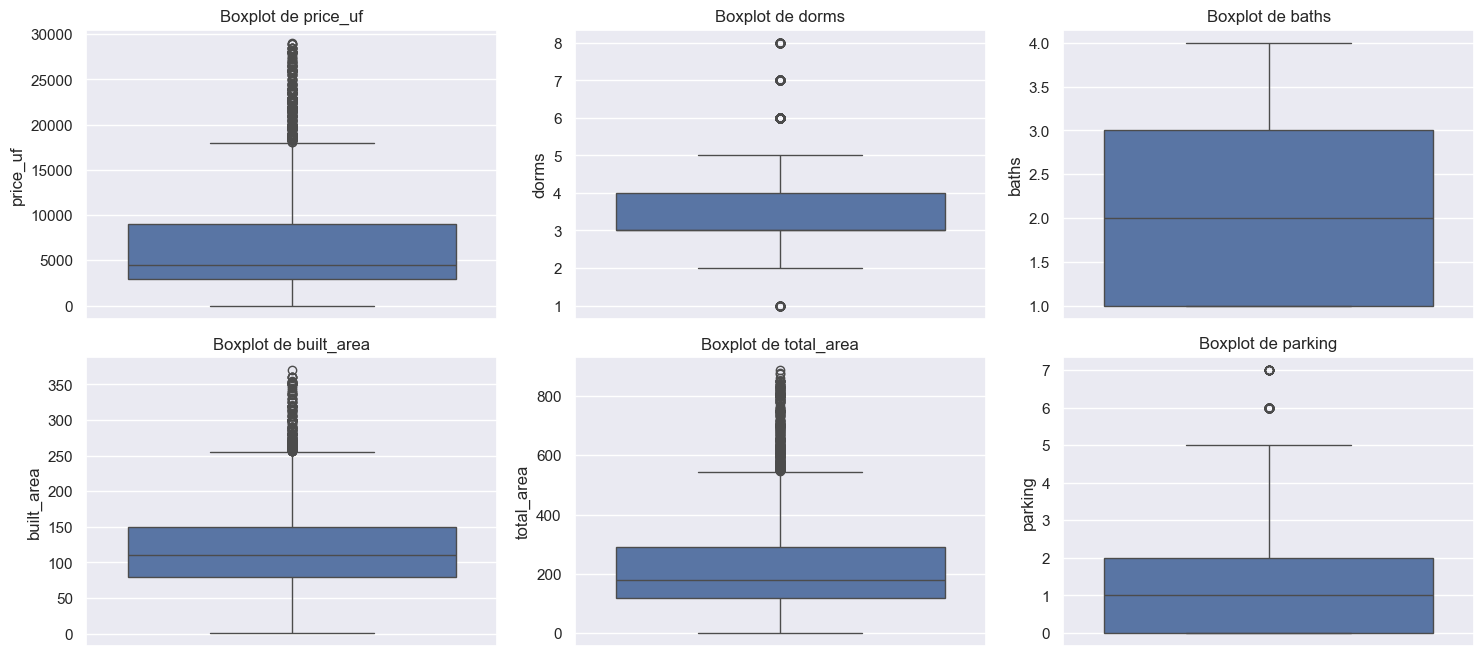

In [54]:
columnas_numericas2 = df2.select_dtypes(include='number')

plt.figure(figsize=(15, 10))  # Ajustar el tamaño de la figura
for i, column in enumerate(columnas_numericas2.columns, 1):
    plt.subplot(3, 3, i)  # Crear subplots para cada boxplot (ajustar según el número de columnas)
    sns.boxplot(data=df2[column])
    plt.title(f'Boxplot de {column}')
    plt.tight_layout()

# Mostrar el gráfico
plt.show()

# for count, column in enumerate(df1.select_dtypes(include='number').columns):
#     sns.boxplot(x=df1[column],ax=ax[i])
#     plt.title(f'Boxplot de {column}')
#     plt.show()

Los outliers restantes, se eliminan.

In [56]:
# # Filtrar las casas con precios mayores a 120,000 UF
# casas_precio_alto = df1[df1['price_uf'] > 120000]

# # Mostrar el listado de las casas con precios superiores a 120,000 UF
# print(casas_precio_alto)

# df1 = df1.loc[df1['id'] != 12288391]
# df1 = df1.loc[df1['id'] != 11679296]

# casas_baths_alto = df1[df1['baths'] > 9]
# print(casas_baths_alto)

# # Eliminar todas las filas donde 'baths' es mayor a 10
# df1 = df1.loc[df1['baths'] <= 9]

# casas_dorms_alto = df1[df1['dorms'] > 12]
# print(casas_dorms_alto)

# # Eliminar todas las filas donde 'dorms' es mayor a 10
# df1 = df1.loc[df1['dorms'] <= 12]

# casas_parking_alto = df1[df1['parking'] > 15]
# print(casas_parking_alto)

In [57]:
# # Calcular el promedio de 'parking' según el número de 'dorms'
# promedio_parking_por_dorms = df1.groupby('dorms')['parking'].mean()

# # Definir los nuevos IDs a los que les quieres cambiar el valor de 'parking'
# ids_a_reemplazar = [
#     9275128, 12283261, 12194828, 12183104, 12136820, 12134929, 12039069, 11978650,
#     11927564, 7153422, 11680591, 7091820, 9635872, 7112581, 4075445, 8896761, 
#     8304327, 9338146, 9328662, 9338062, 11507346, 11100774, 7735656, 9305209, 
#     6086253, 5881334, 6296696, 9087629
# ]

# # Iterar sobre los ids y reemplazar el valor de 'parking' con el promedio según 'dorms'
# for id_value in ids_a_reemplazar:
#     # Obtener el número de dormitorios para el id específico
#     dorms_valor = df1.loc[df1['id'] == id_value, 'dorms'].values[0]
    
#     # Reemplazar el valor de 'parking' con el promedio correspondiente, convertido a entero
#     df1.loc[df1['id'] == id_value, 'parking'] = int(promedio_parking_por_dorms[dorms_valor])

# # Convertir toda la columna 'parking' a enteros
# df1['parking'] = df1['parking'].astype(int)

# # Mostrar las filas para verificar los cambios
# print(df1[df1['id'].isin(ids_a_reemplazar)])


# df1 = df1.loc[df1['id'] != 9275128]
# casas_builtarea_alto = df1.loc[df1['built_area'] > 1500]
# print(casas_builtarea_alto)

In [58]:
# # Calcular el promedio de 'built_area' según el número de 'dorms' y 'comuna'
# promedio_built_area_por_dorms_comuna = df1.groupby(['dorms', 'comuna'])['built_area'].mean()

# # Definir los nuevos IDs a los que les quieres cambiar el valor de 'built_area', eliminando duplicados
# ids_a_reemplazar = list(set([
#     10721217, 12292519, 12052675, 11115336, 11818708, 11935304, 11882035, 11828708, 
#     11817751, 11810219, 10962888, 9139016, 11347739, 8626953, 7658745, 7702181, 
#     7658858, 7702550, 7701653, 7702534, 11634782, 11627390, 11613440, 8343778, 
#     7020562, 9772573, 9758034, 11556939, 11209559, 8646773, 10555135, 9759627, 
#     11209591, 11537202, 10539330, 8486167, 11500895, 10752819, 6095179, 11089439, 
#     6414550, 10459288, 11449478, 11443167, 9937860, 9663510, 10716319, 11362374
# ]))

# # Iterar sobre los ids y reemplazar el valor de 'built_area' con el promedio según 'dorms' y 'comuna'
# for id_value in ids_a_reemplazar:
#     # Verificar si el id está presente en el DataFrame
#     if not df1[df1['id'] == id_value].empty:
#         # Obtener el número de dormitorios y comuna para el id específico
#         dorms_valor = df1.loc[df1['id'] == id_value, 'dorms'].values[0]
#         comuna_valor = df1.loc[df1['id'] == id_value, 'comuna'].values[0]
        
#         # Verificar si la combinación de 'dorms' y 'comuna' está en el promedio calculado
#         if (dorms_valor, comuna_valor) in promedio_built_area_por_dorms_comuna:
#             # Reemplazar el valor de 'built_area' con el promedio correspondiente
#             df1.loc[df1['id'] == id_value, 'built_area'] = promedio_built_area_por_dorms_comuna[(dorms_valor, comuna_valor)]
#     else:
#         print(f"ID {id_value} no se encuentra en el DataFrame.")

# # Mostrar las filas para verificar los cambios
# print(df1[df1['id'].isin(ids_a_reemplazar)])

In [59]:
# casas_uf_alto = df1.loc[df1['price_uf'] > 100000]
# print(casas_uf_alto)
# df1 = df1.loc[df1['price_uf'] <= 100000]
# casas_builtarea_alto = df1.loc[df1['built_area'] > 2600]
# print(casas_builtarea_alto)
# df1 = df1.loc[df1['id'] != 7658745]
# df1 = df1.loc[df1['id'] != 7658858]
# df1 = df1.loc[df1['id'] != 8646773]
# df1 = df1.loc[df1['id'] != 11935304]
# df1 = df1.loc[df1['id'] != 7702550]
# df1 = df1.loc[df1['id'] != 11613440]
# casas_total_alto = df1.loc[df1['total_area'] > 20000]
# print(casas_total_alto)
# df1 = df1.loc[df1['id'] != 9347456]
# df1 = df1.loc[df1['id'] != 12290831]
# df1 = df1.loc[df1['id'] != 12251617]
# df1 = df1.loc[df1['id'] != 9793534]
# df1 = df1.loc[df1['id'] != 4901365]
# df1 = df1.loc[df1['id'] != 10028910]  
# df1 = df1.loc[df1['id'] != 7449603]
# df1 = df1.loc[df1['id'] != 7995682]
# df1 = df1.loc[df1['id'] != 11233359]
# df1 = df1.loc[df1['id'] != 11166251]
# df1 = df1.loc[df1['id'] != 11166330]
# df1 = df1.loc[df1['id'] != 11121825]
# df1 = df1.loc[df1['id'] != 11362374]
# df1 = df1.loc[df1['id'] != 11341949]

In [60]:
# Contar cuántas filas tienen valor 0 en cada una de las columnas
zeros_price_uf = df2[df2['price_uf'] < 100].shape[0]
zeros_total_area = df2[df2['total_area'] < 20].shape[0]
zeros_built_area = df2[df2['built_area'] < 30].shape[0]

# Mostrar los resultados
print(f"Filas con valor menor a 100 en price_uf: {zeros_price_uf}")
print(f"Filas con valor menor a 20 en total_area: {zeros_total_area}")
print(f"Filas con valor 0menor a 30 en built_area: {zeros_built_area}")


Filas con valor menor a 100 en price_uf: 21
Filas con valor menor a 20 en total_area: 8
Filas con valor 0menor a 30 en built_area: 13


In [61]:
# Eliminar las filas con valores menores a los límites establecidos
df2 = df2[(df2['price_uf'] >= 100) & (df2['total_area'] >= 20) & (df2['built_area'] >= 30)]

# Verificar que las filas se eliminaron
outliers_price_uf = df2[df2['price_uf'] < 100].shape[0]
outliers_total_area = df2[df2['total_area'] < 20].shape[0]
outliers_built_area = df2[df2['built_area'] < 30].shape[0]

# Mostrar los resultados después de la eliminación
print(f"Filas con valor menor a 100 en price_uf después de la eliminación: {outliers_price_uf}")
print(f"Filas con valor menor a 20 en total_area después de la eliminación: {outliers_total_area}")
print(f"Filas con valor menor a 30 en built_area después de la eliminación: {outliers_built_area}")


Filas con valor menor a 100 en price_uf después de la eliminación: 0
Filas con valor menor a 20 en total_area después de la eliminación: 0
Filas con valor menor a 30 en built_area después de la eliminación: 0


In [62]:
# Ruta donde deseas guardar el archivo Excel
ruta_guardado = r'..\data\Precios_Casas_RM_final2.xlsx'

# Guardar el DataFrame df3 en un archivo Excel
df2.to_excel(ruta_guardado, index=False)

# Confirmar que el archivo ha sido guardado correctamente
print(f"Archivo guardado en: {ruta_guardado}")

Archivo guardado en: ..\data\Precios_Casas_RM_final2.xlsx


## 4. Feature Engineering

In [64]:
# Cargar el archivo Excel proporcionado
ruta_archivo_excel = r'..\data\Precios_Casas_RM_final2.xlsx'
df_final = pd.read_excel(ruta_archivo_excel)

# Mostrar las primeras filas del DataFrame para verificar que el archivo se ha cargado correctamente
df_final.head()

,price_uf,comuna,dorms,baths,built_area,total_area,parking
0,2950,PedroAguirreCerda,2,1,112.0,145.0,1
1,3600,EstaciónCentral,3,1,59.0,243.0,2
2,2107,Colina,3,1,103.0,73.0,1
3,1489,Colina,2,1,57.0,67.0,1
4,2641,EstaciónCentral,2,1,72.0,131.0,0


Se busca dar valor a las variables built_area y total_area por metro cuadrado.

In [66]:
# Calcular los valores para cada propiedad en términos de price_uf
df_final["price_built_m2_uf"] = df_final["price_uf"] / df_final["built_area"]
df_final["price_total_m2_uf"] = df_final["price_uf"] / df_final["total_area"]

# Mostrar los primeros registros del dataset para verificar las nuevas columnas
print(df_final[['price_built_m2_uf', 'price_total_m2_uf']].head())

   price_built_m2_uf  price_total_m2_uf
0          26.339286          20.344828
1          61.016949          14.814815
2          20.456311          28.863014
3          26.122807          22.223881
4          36.680556          20.160305


In [67]:
df_final.head()

,price_uf,comuna,dorms,baths,built_area,total_area,parking,price_built_m2_uf,price_total_m2_uf
0,2950,PedroAguirreCerda,2,1,112.0,145.0,1,26.339286,20.344828
1,3600,EstaciónCentral,3,1,59.0,243.0,2,61.016949,14.814815
2,2107,Colina,3,1,103.0,73.0,1,20.456311,28.863014
3,1489,Colina,2,1,57.0,67.0,1,26.122807,22.223881
4,2641,EstaciónCentral,2,1,72.0,131.0,0,36.680556,20.160305


* **price_built_m2_uf**  
    - Descripción: Precio por metro cuadrado construido en Unidades de Fomento (UF).  
    - Cálculo: Se divide el precio total de la propiedad en UF por su área construida.  
    - Significado: Esta variable proporciona una medida del valor de la propiedad por unidad de área construida, lo que puede ser útil para comparar propiedades de diferentes tamaños.

* **price_total_m2_uf**  
    - Descripción: Precio por metro cuadrado total en Unidades de Fomento (UF).  
    - Cálculo: Se divide el precio total de la propiedad en UF por su área total.  
    - Significado: Esta variable proporciona una medida del valor de la propiedad por unidad de área total, incluyendo áreas comunes como estacionamientos y jardines.  


In [69]:

##* **price_parking_uf**  
#    - Descripción: Precio por estacionamiento en Unidades de Fomento (UF).  
#    - Cálculo: Se divide el precio total de la propiedad en UF por el número de estacionamientos.  
#    - Significado: Esta variable proporciona una medida del valor de cada estacionamiento en la propiedad.  

#* **price_dorms_uf**  
#    - Descripción: Precio por dormitorio en Unidades de Fomento (UF).  
#    - Cálculo: Se divide el precio total de la propiedad en UF por el número de dormitorios.  
#    - Significado: Esta variable proporciona una medida del valor de cada dormitorio en la propiedad.  

#* **price_baths_uf**  
#    - Descripción: Precio por baño en Unidades de Fomento (UF).  
#    - Cálculo: Se divide el precio total de la propiedad en UF por el número de baños.  
#    - Significado: Esta variable proporciona una medida del valor de cada baño en la propiedad.  

Se busca zonificar comunas según sectores de la Región Metropolitana para poder realizar posteriormente análisis de comparación entre agrupaciones de comunas.

- santiago_norte: Conchalí, Huechuraba, Independencia, Quilicura, Recoleta
- santiago_sur: ElBosque, LaCisterna, LaGranja, LaPintana, LoEspejo, PedroAguirreCerda, SanBernardo, SanJoaquín, SanMiguel, SanRamón
- santiago_centro: Santiago
- santiago_surponiente: Cerrillos, EstaciónCentral, Maipú, PadreHurtado
- santiago_suroriente: LaFlorida, Macul, Peñalolén, PuenteAlto
- santiago_norponiente: CerroNavia, LoPrado, Pudahuel, QuintaNormal, Renca
- santiago_nororiente: Providencia, LasCondes, LaReina, Ñuñoa, Vitacura, LoBarnechea
- provincia_talagante: IsladeMaipo, ElMonte, PadreHurtado, Peñaflor, Talagante
- provincia_melipilla: Melipilla, Alhue, Curacaví, MaríaPinto, SanPedro
- provincia_maipo: SanBernardo, Buin, Paine, CaleradeTango
- provincia_chacabuco: Colina, Lampa, Tiltil
- provincia_cordillera: Pirque, SanJosédeMaipo

In [71]:
# Definir el diccionario de sectores según comunas
zonas= {
'santiago_norte' : ['Conchalí', 'Huechuraba', 'Independencia', 'Quilicura', 'Recoleta'],
'santiago_sur' : ['ElBosque', 'LaCisterna', 'LaGranja', 'LaPintana', 'LoEspejo', 'PedroAguirreCerda', 'SanBernardo', 'SanJoaquín', 'SanMiguel', 'SanRamón'],
'santiago_centro' : ['Santiago'],
'santiago_surponiente' : ['Cerrillos', 'EstaciónCentral', 'Maipú', 'PadreHurtado'],
'santiago_suroriente' : ['LaFlorida', 'Macul', 'Peñalolén', 'PuenteAlto'],
'santiago_norponiente' : ['CerroNavia', 'LoPrado', 'Pudahuel', 'QuintaNormal', 'Renca'],
'santiago_nororiente' : ['Providencia', 'LasCondes', 'LaReina', 'Ñuñoa', 'Vitacura', 'LoBarnechea'],
'provincia_talagante' : ['IsladeMaipo', 'ElMonte', 'PadreHurtado', 'Peñaflor', 'Talagante'],
'provincia_melipilla' : ['Melipilla', 'Alhue', 'Curacaví', 'MaríaPinto', 'SanPedro'],
'provincia_maipo' : ['SanBernardo', 'Buin', 'Paine', 'CaleradeTango'],
'provincia_chacabuco' : ['Colina', 'Lampa', 'Tiltil'],
'provincia_cordillera' : ['Pirque', 'SanJosédeMaipo'],
}

zonas_inv = {comuna: region for region, comunas in zonas.items() for comuna in comunas}
df_final['sector_santiago'] = df_final['comuna'].map(zonas_inv)

# # Definir una función que asigne el sector según la comuna
# def asignar_sector(comuna):
#     if comuna in santiago_norte:
#         return 'Santiago Norte'
#     elif comuna in santiago_sur:
#         return 'Santiago Sur'
#     elif comuna in santiago_centro:
#         return 'Santiago Centro'
#     elif comuna in santiago_surponiente:
#         return 'Santiago Surponiente'
#     elif comuna in santiago_suroriente:
#         return 'Santiago Suroriente'
#     elif comuna in santiago_norponiente:
#         return 'Santiago Norponiente'
#     elif comuna in santiago_nororiente:
#         return 'Santiago Nororiente'
#     elif comuna in provincia_talagante:
#         return 'Provincia Talagante'
#     elif comuna in provincia_melipilla:
#         return 'Provincia Melipilla'
#     elif comuna in provincia_maipo:
#         return 'Provincia Maipo'
#     elif comuna in provincia_chacabuco:
#         return 'Provincia Chacabuco'
#     elif comuna in provincia_cordillera:
#         return 'Provincia Cordillera'
#     else:
#         return 'Otro'

# # Crear la nueva columna 'sector_santiago' en el DataFrame
# df3['sector_santiago'] = df3['comuna'].apply(asignar_sector)

# Mostrar las primeras filas para verificar los cambios
df_final.head(10)

,price_uf,comuna,dorms,baths,built_area,total_area,parking,price_built_m2_uf,price_total_m2_uf,sector_santiago
0,2950,PedroAguirreCerda,2,1,112.0,145.0,1,26.339286,20.344828,santiago_sur
1,3600,EstaciónCentral,3,1,59.0,243.0,2,61.016949,14.814815,santiago_surponiente
2,2107,Colina,3,1,103.0,73.0,1,20.456311,28.863014,provincia_chacabuco
3,1489,Colina,2,1,57.0,67.0,1,26.122807,22.223881,provincia_chacabuco
4,2641,EstaciónCentral,2,1,72.0,131.0,0,36.680556,20.160305,santiago_surponiente
5,2107,Colina,3,1,70.0,80.0,2,30.100000,26.337500,provincia_chacabuco
6,2950,LaFlorida,2,1,50.0,120.0,1,59.000000,24.583333,santiago_suroriente
7,2135,Maipú,3,1,72.0,72.0,1,29.652778,29.652778,santiago_surponiente
8,2135,Maipú,3,1,46.0,90.0,1,46.413043,23.722222,santiago_surponiente
9,2529,Maipú,3,1,100.0,134.0,3,25.290000,18.873134,santiago_surponiente


## 4. Visualizaciones Exploratorias

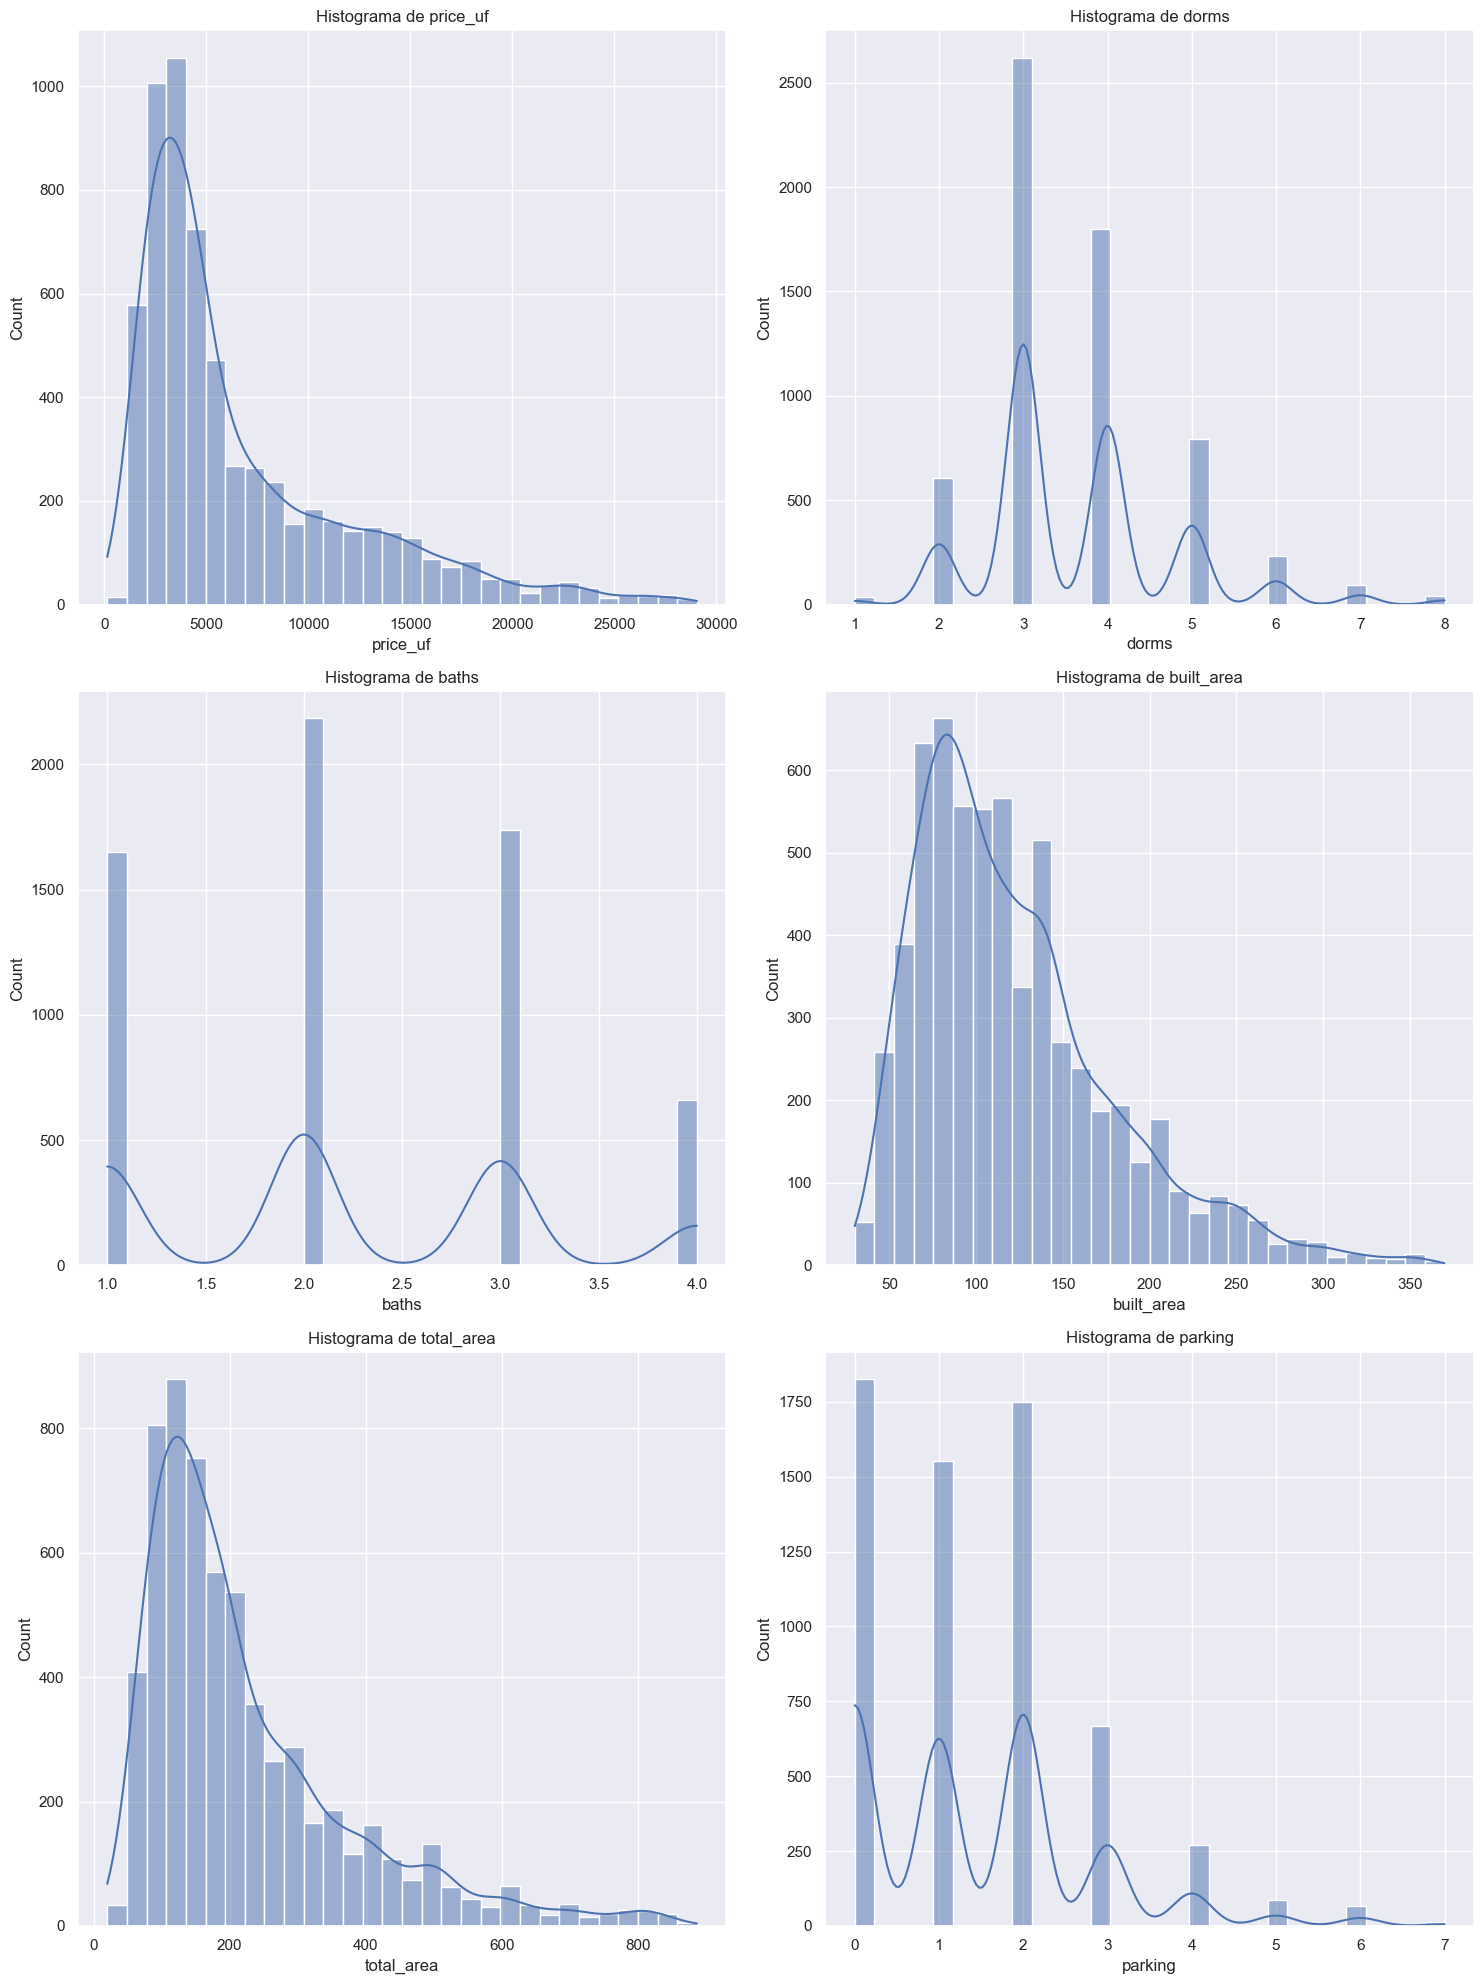

In [73]:
# Seleccionar todas las columnas numéricas excepto 'id'
num_columns = df_final.select_dtypes(include=np.number)

# Definir el tamaño de la figura
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15, 20), squeeze=False)  # Crear una cuadrícula de gráficos (4 filas, 2 columnas)

# Iterar sobre cada columna numérica para crear Histograma
for ax, column in zip(axs.flat, num_columns.columns):
    sns.histplot(num_columns[column], ax=ax, bins=30, kde=True) 
    ax.set_title(f'Histograma de {column}')

# Ajustar el espacio entre los gráficos
plt.tight_layout()
plt.show()

En los histogramas presentados, se observa la distribución de las variables price_uf y dorms en el conjunto de datos. El gráfico de la izquierda, correspondiente a price_uf, muestra una distribución asimétrica positiva, con una concentración notable de propiedades en el rango de precios entre 2.000 y 5.000 UF, lo que sugiere que la mayoría de las propiedades tienen precios relativamente moderados. A medida que el precio aumenta, la cantidad de propiedades disminuye considerablemente, aunque se observan algunos valores altos que podrían ser considerados como atípicos.

El gráfico de la derecha, que representa la distribución de dorms, revela una distribución discreta con valores predominantes en los números 3, 4 y 5 dormitorios. El pico más alto se encuentra en las propiedades con 3 dormitorios, seguidas por aquellas con 4 y 5 dormitorios, lo que indica que estos son los tamaños más comunes en el dataset. Hay una presencia muy limitada de propiedades con 2 dormitorios, lo que sugiere que son menos comunes en la muestra analizada.

correlacion sacar el mts2 por ..

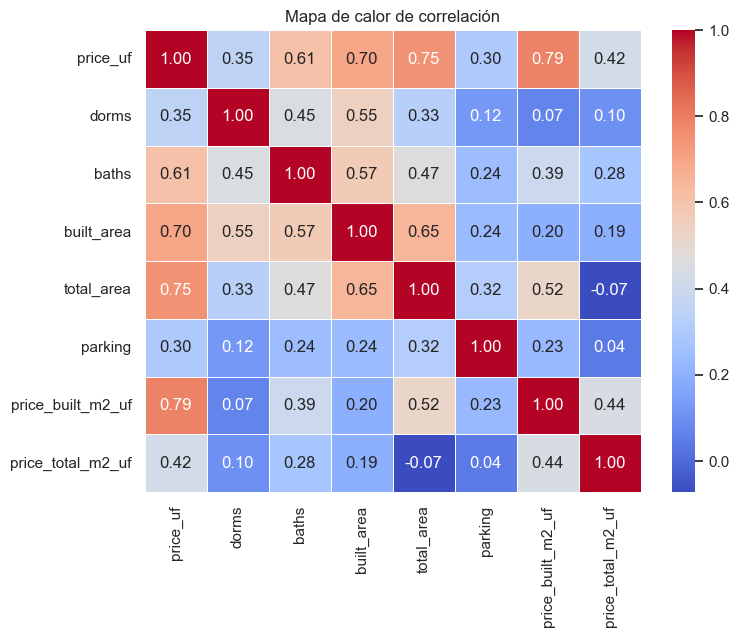

In [76]:
# Seleccionar todas las columnas numéricas excepto 'id'
num_columns = df_final.select_dtypes(include=np.number)

# Calcular la matriz de correlación sin la columna 'id'
correlation_matrix = num_columns.corr(numeric_only=True)

# Crear un mapa de calor para mostrar la correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de calor de correlación')
plt.show()

In [77]:
# Definir las columnas que se van a analizar
columns_to_analyze = ['price_uf', 'dorms', 'baths', 'built_area', 'total_area', 'parking']

# Definir la función para calcular la moda
def moda(series):
    return series.mode()[0] if not series.mode().empty else None

# Crear la tabla agrupada por 'comuna'
tabla_por_comuna = df_final.groupby('comuna').agg(
    price_uf_mean=('price_uf', 'mean'),
    price_uf_max=('price_uf', 'max'),
    price_uf_min=('price_uf', 'min'),
    dorms_median=('dorms', 'median'),
    dorms_mean=('dorms', 'mean'),
    dorms_max=('dorms', 'max'),
    dorms_min=('dorms', 'min'),
    baths_median=('baths', 'median'),
    baths_mean=('baths', 'mean'),
    baths_max=('baths', 'max'),
    baths_min=('baths', 'min'),
    built_area_mean=('built_area', 'mean'),
    built_area_max=('built_area', 'max'),
    built_area_min=('built_area', 'min'),
    total_area_mean=('total_area', 'mean'),
    total_area_max=('total_area', 'max'),
    total_area_min=('total_area', 'min'),
    parking_median=('parking', 'median'),
    parking_mean=('parking', 'mean'),
    parking_max=('parking', 'max'),
    parking_min=('parking', 'min')
).reset_index()


display(tabla_por_comuna)

,comuna,price_uf_mean,price_uf_max,price_uf_min,dorms_median,dorms_mean,dorms_max,dorms_min,baths_median,baths_mean,...,built_area_mean,built_area_max,built_area_min,total_area_mean,total_area_max,total_area_min,parking_median,parking_mean,parking_max,parking_min
0,Buin,4366.923077,12700,1321,3.0,3.230769,5,2,2.0,2.282051,...,93.085470,210.0,44.0,186.786325,740.0,45.0,1.0,1.487179,6,0
1,CaleradeTango,3793.800000,5058,2593,4.0,3.800000,5,3,2.0,1.800000,...,96.800000,125.0,72.0,278.000000,500.0,100.0,1.0,1.600000,4,0
2,Cerrillos,4238.587302,10000,1470,3.0,3.539683,6,2,2.0,1.809524,...,113.984127,350.0,48.0,198.380952,672.0,59.0,2.0,1.507937,6,0
3,CerroNavia,3038.632653,6587,1517,3.0,3.551020,7,1,1.0,1.653061,...,124.642857,306.0,37.0,176.040816,499.0,53.0,1.0,1.204082,4,0
4,Colina,9718.021341,22600,309,3.0,3.396341,6,2,3.0,2.856707,...,146.937500,370.0,38.0,351.125000,831.0,55.0,2.0,1.542683,6,0
5,Conchalí,4486.232558,11211,2304,4.0,3.976744,7,2,2.0,1.697674,...,133.325581,248.0,52.0,233.790698,800.0,90.0,1.0,1.651163,5,0
6,Curacaví,5278.666667,8270,2529,3.5,3.833333,5,3,2.5,2.666667,...,174.000000,290.0,64.0,200.833333,290.0,90.0,0.0,0.166667,1,0
7,ElBosque,3315.904762,8991,1124,3.0,3.619048,7,2,1.0,1.559524,...,109.119048,300.0,35.0,189.244048,546.0,42.0,1.0,1.345238,6,0
8,ElMonte,2530.235294,6000,1545,3.0,3.647059,6,2,1.0,1.588235,...,88.352941,190.0,36.0,165.764706,650.0,55.0,1.0,0.941176,2,0
9,EstaciónCentral,4832.626263,25700,1700,3.0,3.606061,7,1,2.0,1.767677,...,117.595960,345.0,32.0,205.373737,828.0,34.0,1.0,1.272727,7,0


In [78]:
# # Aplicar la función para crear la columna 'sector_santiago'
# df3['sector_santiago'] = df3['comuna'].apply(asignar_sector)

# Definir las columnas que se van a analizar
columns_to_analyze = ['price_uf', 'dorms', 'baths', 'built_area', 'total_area', 'parking']

# Definir la función para calcular la moda
def moda(series):
    return series.mode()[0] if not series.mode().empty else None

# Crear la tabla agrupada por 'sector_santiago'
tabla_por_sector = df_final.groupby('sector_santiago').agg(
    price_uf_mean=('price_uf', 'mean'),
    price_uf_max=('price_uf', 'max'),
    price_uf_min=('price_uf', 'min'),
    dorms_mean=('dorms', 'mean'),
    dorms_max=('dorms', 'max'),
    dorms_min=('dorms', 'min'),
    baths_mean=('baths', 'mean'),
    baths_max=('baths', 'max'),
    baths_min=('baths', 'min'),
    built_area_mean=('built_area', 'mean'),
    built_area_max=('built_area', 'max'),
    built_area_min=('built_area', 'min'),
    total_area_mean=('total_area', 'mean'),
    total_area_mode=('total_area', moda),
    total_area_max=('total_area', 'max'),
    total_area_min=('total_area', 'min'),
    parking_mean=('parking', 'mean'),
    parking_max=('parking', 'max'),
).reset_index()

# Ordenar la tabla por la cantidad de ID únicos, de mayor a menor
tabla_por_sector_ordenada = tabla_por_sector

display(tabla_por_sector_ordenada)

,sector_santiago,price_uf_mean,price_uf_max,price_uf_min,dorms_mean,dorms_max,dorms_min,baths_mean,baths_max,baths_min,built_area_mean,built_area_max,built_area_min,total_area_mean,total_area_mode,total_area_max,total_area_min,parking_mean,parking_max
0,provincia_chacabuco,7593.633603,22600,309,3.340081,7,1,2.580972,4,1,128.035425,370.0,36.0,288.637652,350.0,831.0,44.0,1.489879,6
1,provincia_cordillera,5655.000000,16141,2782,4.285714,5,3,2.000000,4,1,135.714286,300.0,75.0,381.000000,500.0,850.0,130.0,2.000000,3
2,provincia_maipo,3576.031746,15757,152,3.315193,8,1,1.938776,4,1,92.365079,342.0,32.0,166.675737,120.0,836.0,42.0,1.303855,6
3,provincia_melipilla,3066.567568,8270,1264,3.432432,6,2,1.810811,4,1,100.297297,290.0,38.0,173.608108,200.0,529.0,66.0,0.972973,3
4,provincia_talagante,3658.741071,10000,300,3.281250,8,2,2.058036,4,1,95.037946,267.0,36.0,175.823661,90.0,710.0,50.0,1.321429,6
5,santiago_centro,6447.482587,26000,295,4.208955,8,1,2.164179,4,1,151.552239,360.0,37.0,200.808458,200.0,726.0,32.0,0.820896,5
6,santiago_nororiente,14775.244592,29046,1377,4.087354,8,1,2.834443,4,1,167.624792,361.0,30.0,346.474626,300.0,887.0,20.0,1.887687,7
7,santiago_norponiente,4222.948087,16859,1264,3.620219,8,1,1.868852,4,1,112.450820,306.0,30.0,197.763661,120.0,850.0,41.0,1.251366,6
8,santiago_norte,5238.810268,21045,1450,3.723214,8,1,2.209821,4,1,120.122768,318.0,35.0,196.955357,200.0,876.0,37.0,1.272321,7
9,santiago_sur,4637.036145,22197,1096,3.684739,8,1,1.746988,4,1,122.947791,350.0,30.0,230.221888,200.0,836.0,40.0,1.395582,7


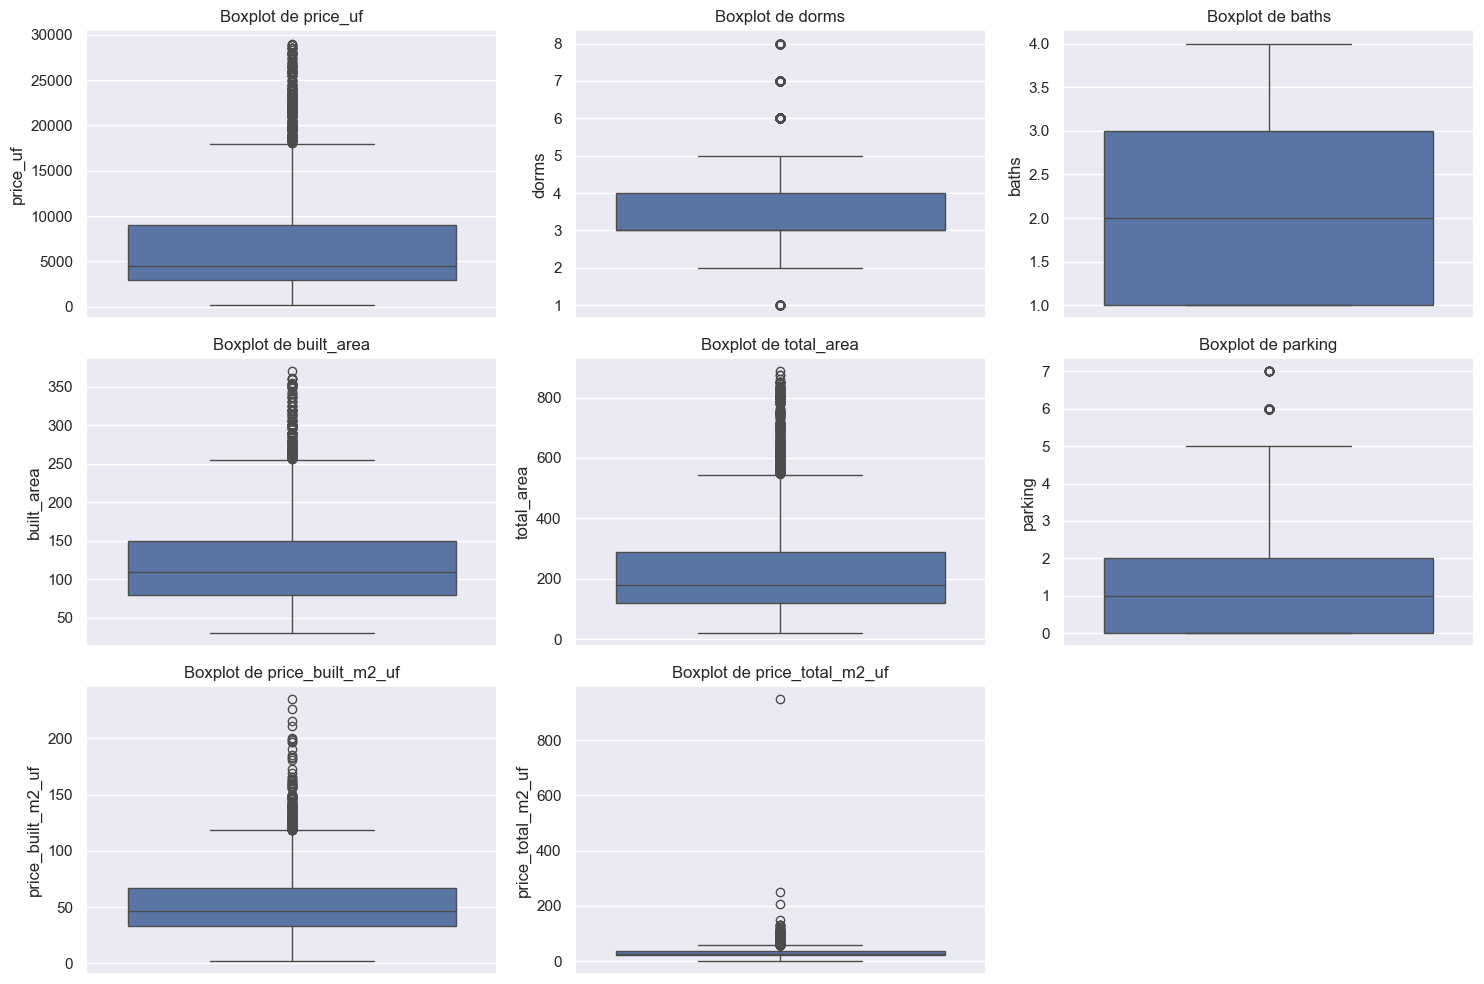

In [79]:
# Seleccionar solo las columnas numéricas del DataFrame df3
columnas_numericas = df_final.select_dtypes(include=[np.number])

# Crear un boxplot para cada columna numérica
plt.figure(figsize=(15, 10))  # Ajustar el tamaño de la figura
for i, column in enumerate(columnas_numericas.columns, 1):
    plt.subplot(3, 3, i)  # Crear subplots para cada boxplot (ajustar según el número de columnas)
    sns.boxplot(data=df_final[column])
    plt.title(f'Boxplot de {column}')
    plt.tight_layout()

# Mostrar el gráfico
plt.show()

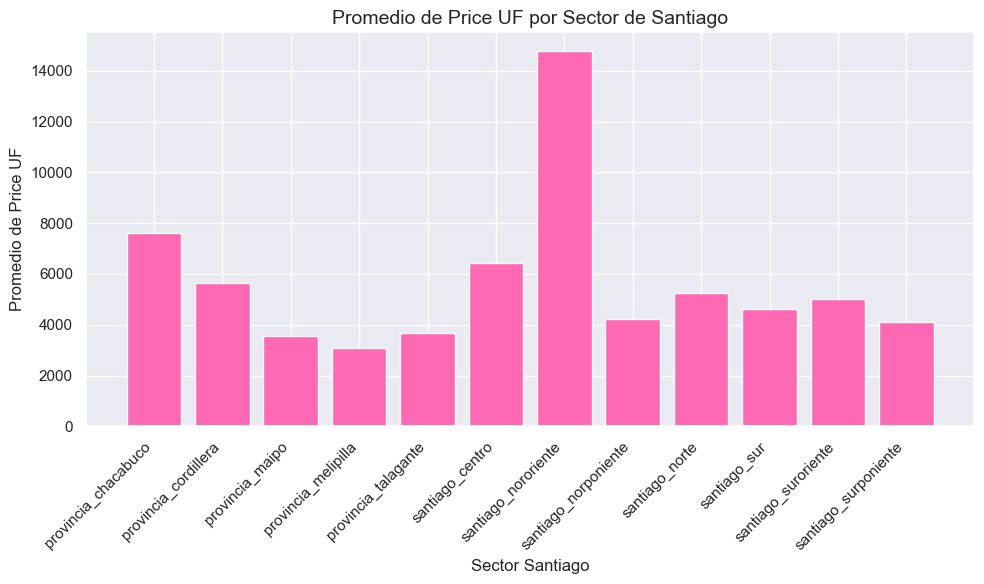

In [80]:
# Crear gráfico de barras para visualizar price_uf_mean por sector_santiago
plt.figure(figsize=(10, 6))

# Gráfico de barras
plt.bar(tabla_por_sector_ordenada['sector_santiago'], tabla_por_sector_ordenada['price_uf_mean'], color='hotpink')

# Personalización del gráfico
plt.title('Promedio de Price UF por Sector de Santiago', fontsize=14)
plt.xlabel('Sector Santiago', fontsize=12)
plt.ylabel('Promedio de Price UF', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Mostrar gráfico
plt.show()

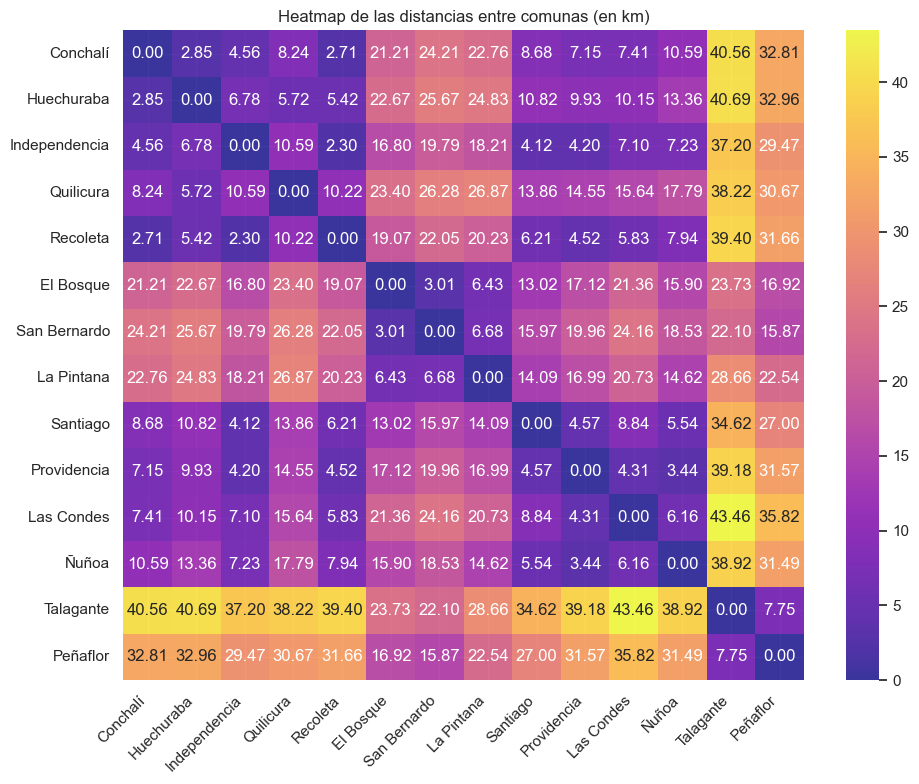

In [81]:
from geopy.distance import geodesic

# Definir la variable ubicacion_provincias
ubicacion_provincias = {
    'santiago_norte': {
        'Conchalí': {'lat': -33.3788, 'lon': -70.6542},
        'Huechuraba': {'lat': -33.3626, 'lon': -70.6780},
        'Independencia': {'lat': -33.4199, 'lon': -70.6527},
        'Quilicura': {'lat': -33.3579, 'lon': -70.7392},
        'Recoleta': {'lat': -33.4011, 'lon': -70.6422}
    },
    'santiago_sur': {
        'El Bosque': {'lat': -33.5662, 'lon': -70.6995},
        'San Bernardo': {'lat': -33.5930, 'lon': -70.7043},
        'La Pintana': {'lat': -33.5833, 'lon': -70.6333}
    },
    'santiago_centro': {
        'Santiago': {'lat': -33.4569, 'lon': -70.6483}
    },
    'santiago_nororiente': {
        'Providencia': {'lat': -33.4314, 'lon': -70.6097},
        'Las Condes': {'lat': -33.4019, 'lon': -70.5795},
        'Ñuñoa': {'lat': -33.4569, 'lon': -70.5887}
    },
    'provincia_talagante': {
        'Talagante': {'lat': -33.6647, 'lon': -70.9265},
        'Peñaflor': {'lat': -33.6103, 'lon': -70.8740}
    }
}

# Extraer comunas y coordenadas
comunas = []
coordenadas = []

for sector, comunas_dict in ubicacion_provincias.items():
    for comuna, coords in comunas_dict.items():
        comunas.append(comuna)
        coordenadas.append((coords['lat'], coords['lon']))

# Calcular la matriz de distancias geográficas entre comunas
distancias = np.zeros((len(comunas), len(comunas)))

for i in range(len(comunas)):
    for j in range(len(comunas)):
        if i != j:
            distancias[i, j] = geodesic(coordenadas[i], coordenadas[j]).kilometers

# Crear un heatmap de las distancias
plt.figure(figsize=(10, 8))
sns.heatmap(distancias, xticklabels=comunas, yticklabels=comunas, cmap="plasma", annot=True, fmt=".2f", alpha=0.8)
plt.title('Heatmap de las distancias entre comunas (en km)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

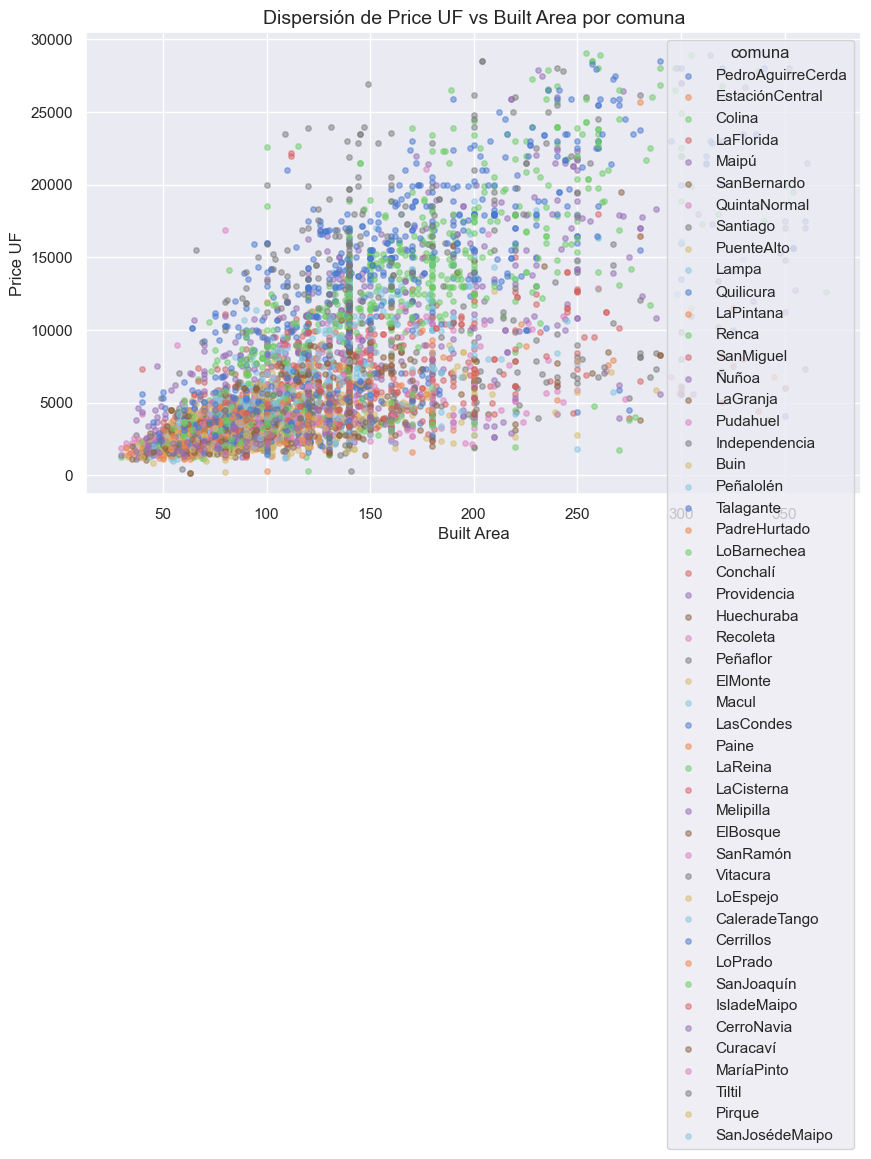

In [155]:
# Definir una paleta de colores para los sectores únicos
sectores_unicos = df_final['comuna'].unique()
colores = sns.color_palette("muted", len(sectores_unicos))

# Crear un diccionario para asignar colores a cada sector
colores_sectores = {sector: colores[i] for i, sector in enumerate(sectores_unicos)}

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
for sector in sectores_unicos:
    sector_data = df_final[df_final['comuna'] == sector]
    plt.scatter(sector_data['built_area'], sector_data['price_uf'], 
                color=colores_sectores[sector], label=sector, s=15, alpha=0.5)

# Etiquetas del gráfico
plt.title('Dispersión de Price UF vs Built Area por comuna', fontsize=14)
plt.xlabel('Built Area', fontsize=12)
plt.ylabel('Price UF', fontsize=12)

# Mostrar leyenda
plt.legend(title="comuna")

# Mostrar gráfico
plt.grid(True)
plt.show()

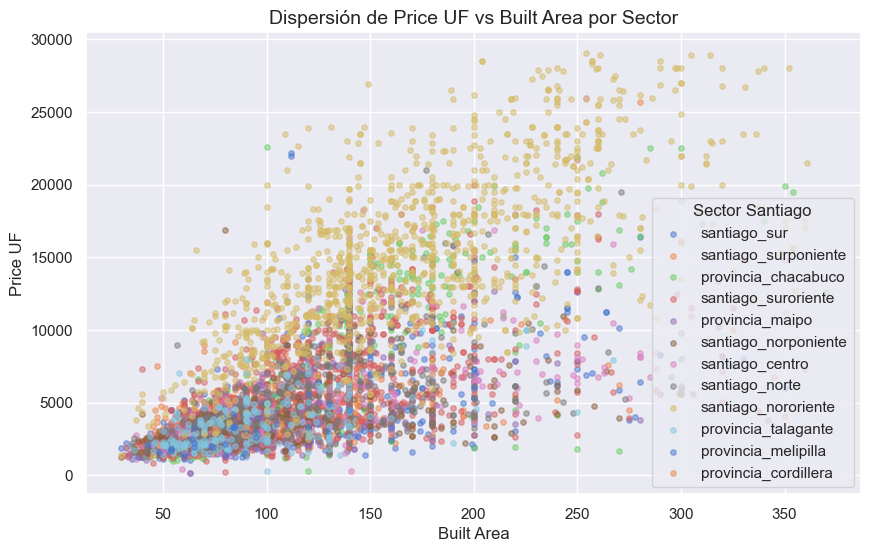

In [157]:
# Definir una paleta de colores para los sectores únicos
sectores_unicos = df_final['sector_santiago'].unique()
colores = sns.color_palette("muted", len(sectores_unicos))

# Crear un diccionario para asignar colores a cada sector
colores_sectores = {sector: colores[i] for i, sector in enumerate(sectores_unicos)}

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
for sector in sectores_unicos:
    sector_data = df_final[df_final['sector_santiago'] == sector]
    plt.scatter(sector_data['built_area'], sector_data['price_uf'], 
                color=colores_sectores[sector], label=sector, s=15, alpha=0.5)

# Etiquetas del gráfico
plt.title('Dispersión de Price UF vs Built Area por Sector', fontsize=14)
plt.xlabel('Built Area', fontsize=12)
plt.ylabel('Price UF', fontsize=12)

# Mostrar leyenda
plt.legend(title="Sector Santiago")

# Mostrar gráfico
plt.grid(True)
plt.show()

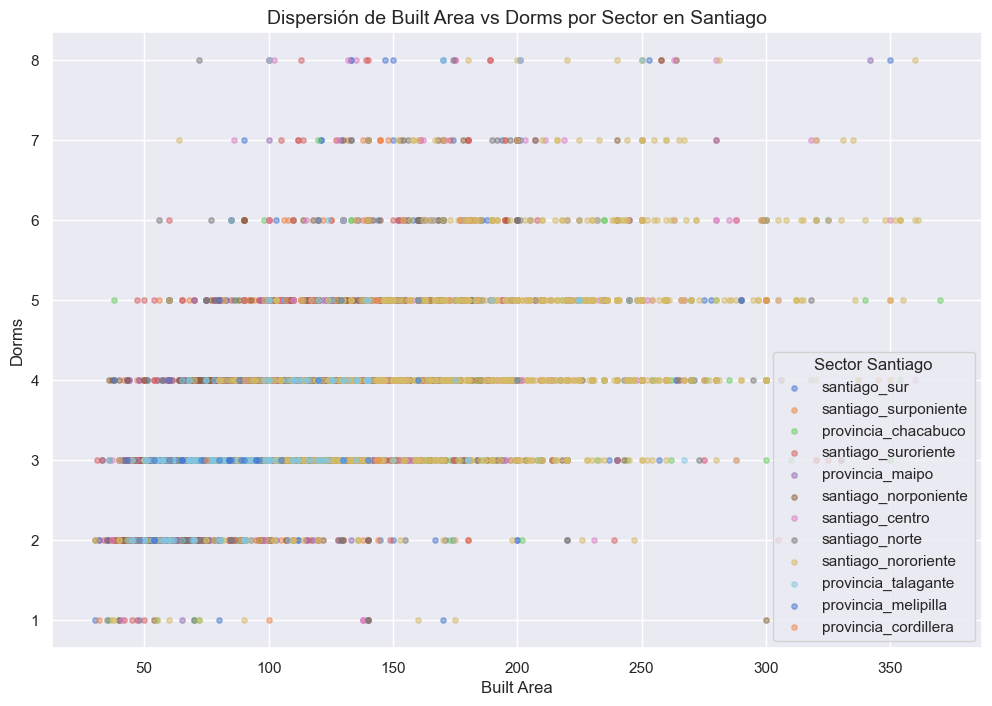

In [83]:
# Crear una paleta de colores para los sectores únicos
sectores_unicos = df_final['sector_santiago'].unique()
colores = sns.color_palette("muted", len(sectores_unicos))

# Crear un diccionario para asignar colores a cada sector
colores_sectores = {sector: colores[i] for i, sector in enumerate(sectores_unicos)}

# Crear el gráfico de dispersión
plt.figure(figsize=(12, 8))
for sector in sectores_unicos:
    sector_data = df_final[df_final['sector_santiago'] == sector]
    plt.scatter(sector_data['built_area'], sector_data['dorms'], 
                color=colores_sectores[sector], label=sector, s=15, alpha=0.5)

# Etiquetas del gráfico
plt.title('Dispersión de Built Area vs Dorms por Sector en Santiago', fontsize=14)
plt.xlabel('Built Area', fontsize=12)
plt.ylabel('Dorms', fontsize=12)

# Mostrar la leyenda
plt.legend(title="Sector Santiago")

# Mostrar gráfico
plt.grid(True)
plt.show()

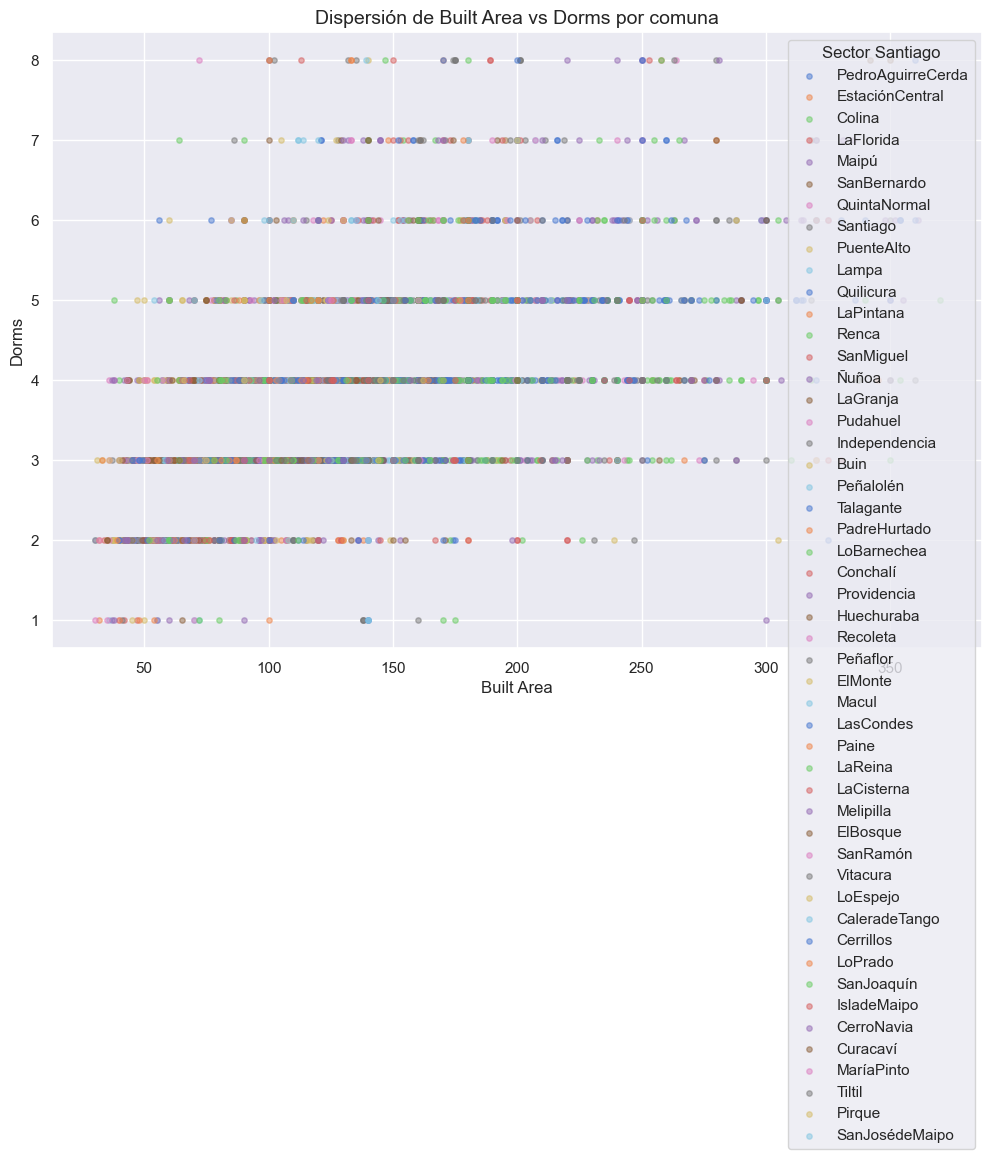

In [159]:
# Crear una paleta de colores para los sectores únicos
sectores_unicos = df_final['comuna'].unique()
colores = sns.color_palette("muted", len(sectores_unicos))

# Crear un diccionario para asignar colores a cada sector
colores_sectores = {sector: colores[i] for i, sector in enumerate(sectores_unicos)}

# Crear el gráfico de dispersión
plt.figure(figsize=(12, 8))
for sector in sectores_unicos:
    sector_data = df_final[df_final['comuna'] == sector]
    plt.scatter(sector_data['built_area'], sector_data['dorms'], 
                color=colores_sectores[sector], label=sector, s=15, alpha=0.5)

# Etiquetas del gráfico
plt.title('Dispersión de Built Area vs Dorms por comuna', fontsize=14)
plt.xlabel('Built Area', fontsize=12)
plt.ylabel('Dorms', fontsize=12)

# Mostrar la leyenda
plt.legend(title="Sector Santiago")

# Mostrar gráfico
plt.grid(True)
plt.show()

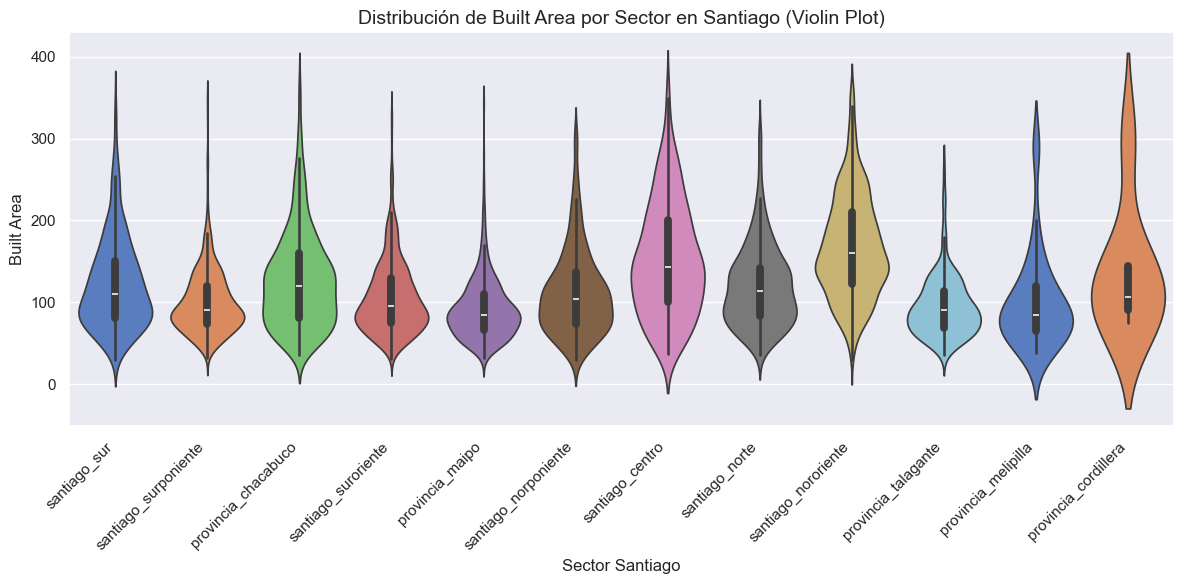

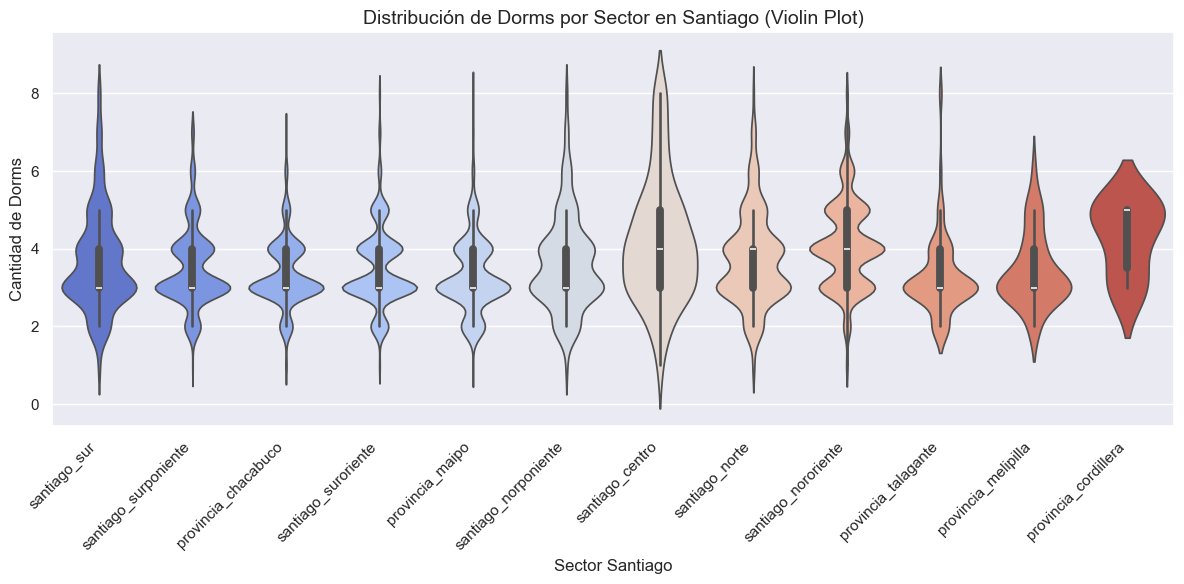

In [84]:
# Gráfico de violín para built_area por sector_santiago
plt.figure(figsize=(12, 6))
sns.violinplot(x='sector_santiago', y='built_area', data=df_final, hue='sector_santiago', palette="muted", dodge=False, legend=False)
plt.title('Distribución de Built Area por Sector en Santiago (Violin Plot)', fontsize=14)
plt.xlabel('Sector Santiago', fontsize=12)
plt.ylabel('Built Area', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Gráfico de violín para dorms por sector_santiago
plt.figure(figsize=(12, 6))
sns.violinplot(x='sector_santiago', y='dorms', data=df_final, hue='sector_santiago', palette="coolwarm", dodge=False, legend=False)
plt.title('Distribución de Dorms por Sector en Santiago (Violin Plot)', fontsize=14)
plt.xlabel('Sector Santiago', fontsize=12)
plt.ylabel('Cantidad de Dorms', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Anchura y densidad: Sectores como Santiago Norponiente, Santiago Sur y Provincia Maipo tienen formas relativamente anchas y cortas, lo que indica que la mayoría de las propiedades en esos sectores tienen áreas construidas más pequeñas y concentradas en rangos específicos.

Distribuciones más grandes: Sectores como Santiago Centro, Santiago Nororiente, y Provincia Talagante tienen violines más alargados, lo que significa que hay propiedades con áreas construidas significativamente mayores en esos sectores. Por ejemplo, en Provincia Talagante y Santiago Centro, algunas propiedades tienen un área construida superior a 2000 metros cuadrados, lo que representa un rango de tamaños más amplio.

Sectores con áreas construidas menores: Sectores como Santiago Norte y Santiago Norponiente tienen áreas construidas más pequeñas en general, ya que los violines son estrechos y concentrados en el extremo inferior del eje Y.

Rangos de los datos: Algunas áreas, como Provincia Chacabuco y Provincia Maipo, tienen una concentración de propiedades con un área construida de menos de 500 metros cuadrados, mientras que otros sectores como Provincia Talagante y Santiago Centro tienen una mayor dispersión en las áreas construidas.

Santiago Centro y Provincia Talagante presentan una gran variedad de tamaños de propiedades, mientras que otros sectores tienen distribuciones más concentradas, lo que sugiere que la mayoría de las propiedades tienen tamaños similares.

Sectores como Santiago Norte, Santiago Norponiente y Santiago Sur tienen propiedades con áreas construidas más pequeñas y más concentradas, lo que podría sugerir un mayor enfoque en viviendas más compactas.

Sectores como Santiago Nororiente y Provincia Talagante parecen incluir propiedades con áreas más grandes en promedio, lo que podría reflejar un mayor desarrollo de propiedades con más espacio en esas áreas.

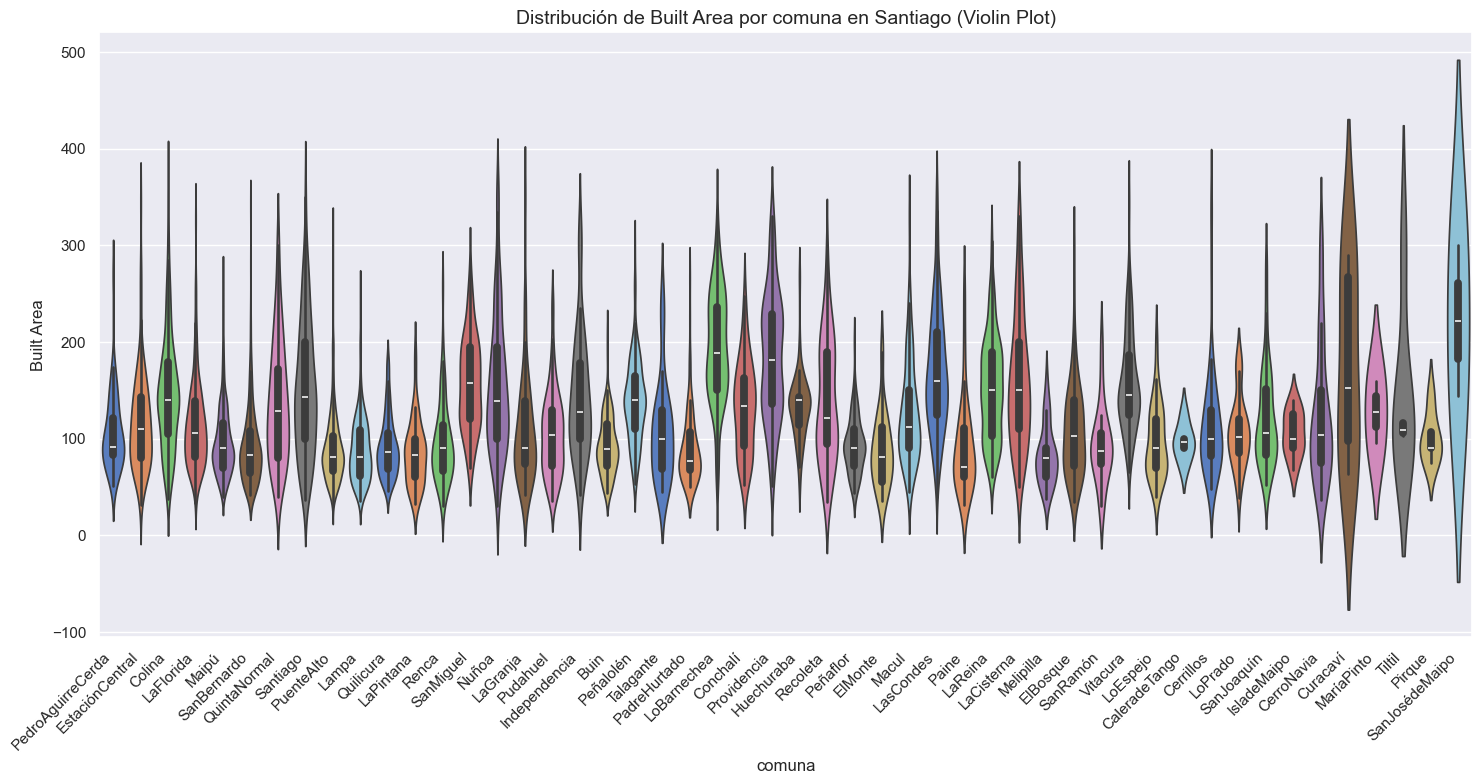

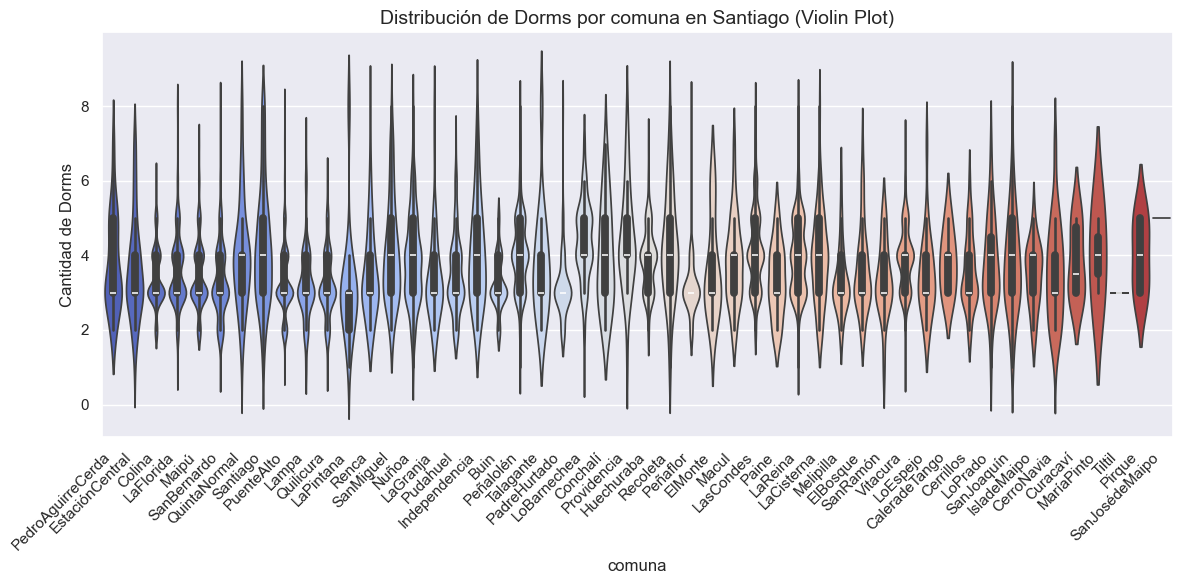

In [165]:
# Gráfico de violín para built_area por sector_santiago
plt.figure(figsize=(15, 8))
sns.violinplot(x='comuna', y='built_area', data=df_final, hue='comuna', palette="muted", dodge=False, legend=False)
plt.title('Distribución de Built Area por comuna en Santiago (Violin Plot)', fontsize=14)
plt.xlabel('comuna', fontsize=12)
plt.ylabel('Built Area', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Gráfico de violín para dorms por sector_santiago
plt.figure(figsize=(12, 6))
sns.violinplot(x='comuna', y='dorms', data=df_final, hue='comuna', palette="coolwarm", dodge=False, legend=False)
plt.title('Distribución de Dorms por comuna en Santiago (Violin Plot)', fontsize=14)
plt.xlabel('comuna', fontsize=12)
plt.ylabel('Cantidad de Dorms', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

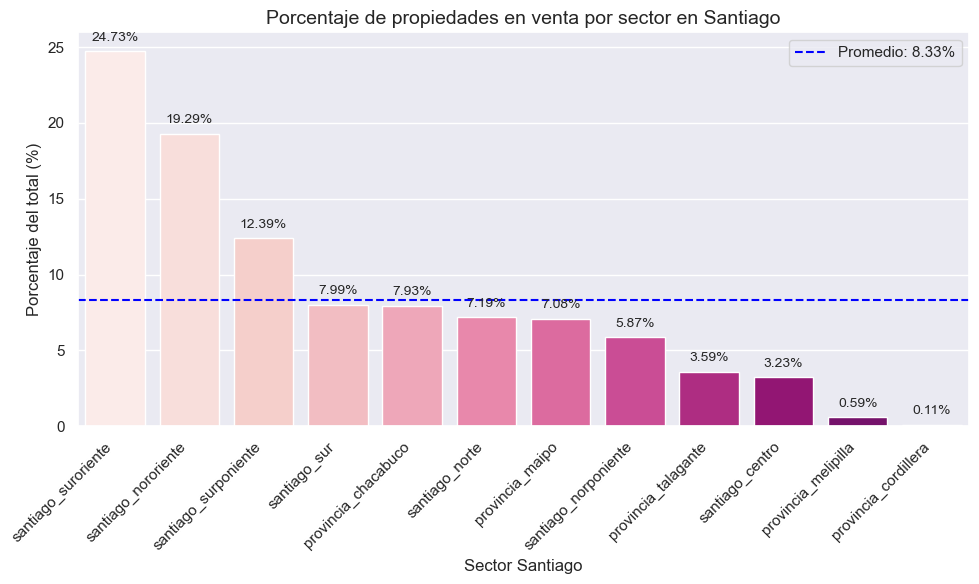

In [86]:
# Calcular el porcentaje de propiedades en venta por 'sector_santiago'
total_propiedades = df_final.shape[0]
propiedades_por_sector = df_final['sector_santiago'].value_counts(normalize=True) * 100

# Calcular el promedio del porcentaje de propiedades en venta
promedio_porcentaje = propiedades_por_sector.mean()

# Crear un gráfico de barras para mostrar el porcentaje por sector_santiago
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=propiedades_por_sector.index, y=propiedades_por_sector.values, dodge=False, hue=propiedades_por_sector.index, palette="RdPu", legend=False)

# Añadir el valor porcentual sobre cada barra
for index, value in enumerate(propiedades_por_sector.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontsize=10)

# Añadir la línea horizontal con el promedio
plt.axhline(promedio_porcentaje, color='blue', linestyle='--', label=f'Promedio: {promedio_porcentaje:.2f}%')

# Etiquetas del gráfico
plt.title('Porcentaje de propiedades en venta por sector en Santiago', fontsize=14)
plt.xlabel('Sector Santiago', fontsize=12)
plt.ylabel('Porcentaje del total (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir leyenda
plt.legend()

# Mostrar gráfico
plt.tight_layout()
plt.show()


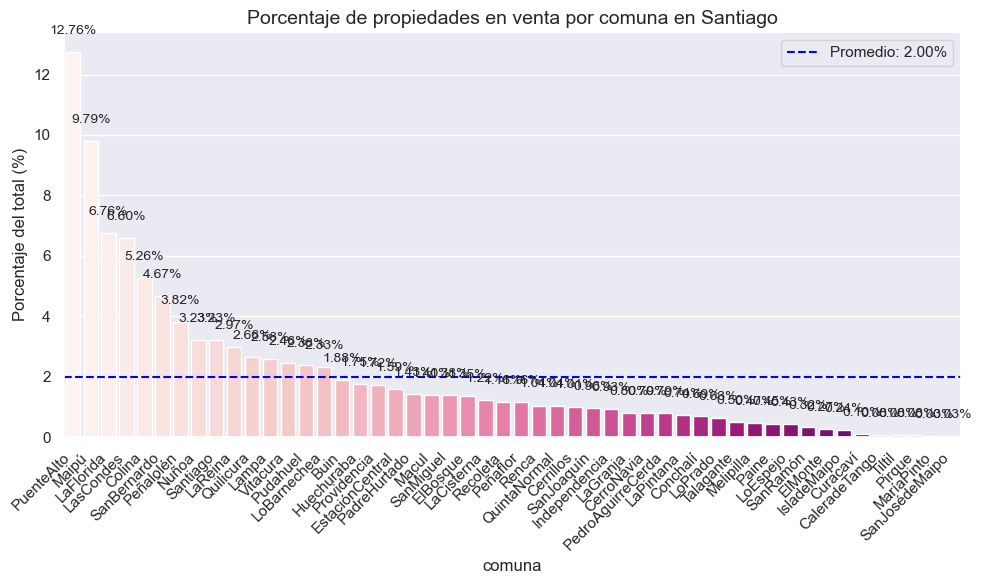

In [167]:
# Calcular el porcentaje de propiedades en venta por 'sector_santiago'
total_propiedades = df_final.shape[0]
propiedades_por_sector = df_final['comuna'].value_counts(normalize=True) * 100

# Calcular el promedio del porcentaje de propiedades en venta
promedio_porcentaje = propiedades_por_sector.mean()

# Crear un gráfico de barras para mostrar el porcentaje por sector_santiago
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=propiedades_por_sector.index, y=propiedades_por_sector.values, dodge=False, hue=propiedades_por_sector.index, palette="RdPu", legend=False)

# Añadir el valor porcentual sobre cada barra
for index, value in enumerate(propiedades_por_sector.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontsize=10)

# Añadir la línea horizontal con el promedio
plt.axhline(promedio_porcentaje, color='blue', linestyle='--', label=f'Promedio: {promedio_porcentaje:.2f}%')

# Etiquetas del gráfico
plt.title('Porcentaje de propiedades en venta por comuna en Santiago', fontsize=14)
plt.xlabel('comuna', fontsize=12)
plt.ylabel('Porcentaje del total (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir leyenda
plt.legend()

# Mostrar gráfico
plt.tight_layout()
plt.show()


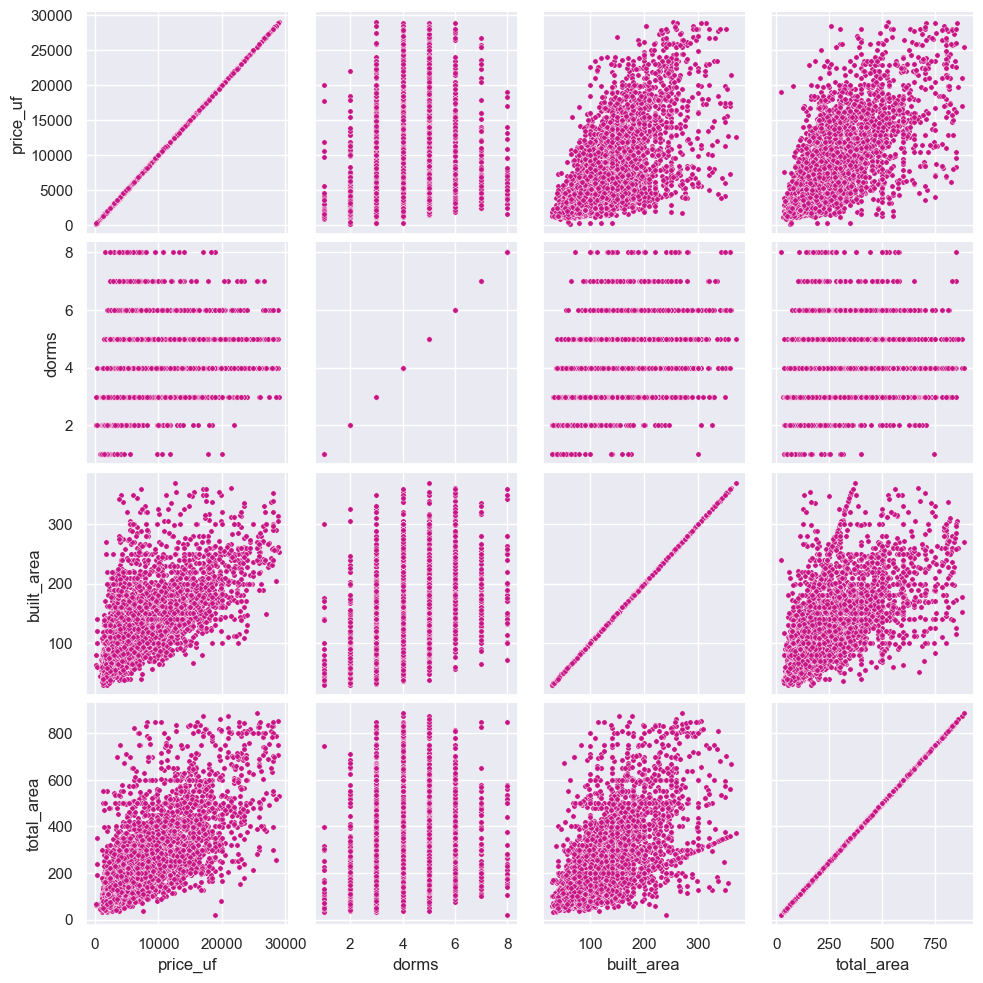

In [87]:
columnas_a_excluir = ['parking', 'baths', 'price_built_m2_uf', 'price_total_m2_uf']
df_numerico = df_final.select_dtypes(include=np.number).drop(columns=columnas_a_excluir)

# Crear el pairplot con color hotpink
sns.pairplot(df_numerico, diag_kind=None, plot_kws={'color': 'mediumvioletred', "s": 15})

# Mostrar el gráfico
plt.show()


**Relación entre price_uf y built_area:**
Hay una tendencia clara donde el precio (price_uf) aumenta a medida que crece el área construida (built_area). Esto indica una relación positiva entre el precio y el tamaño de la propiedad.

**Relación entre price_uf y total_area:**
Similar a built_area, también parece haber una relación positiva entre el precio (price_uf) y el área total (total_area). Las propiedades con un área total mayor tienden a tener precios más altos.

**Relación entre price_uf y dorms:**
Aunque la relación no es tan clara como en las otras variables, se observa que las propiedades con más dormitorios tienden a tener precios más altos, aunque hay bastante dispersión en la cantidad de dormitorios para un mismo precio.

**Relación entre built_area y total_area:**
Existe una fuerte correlación entre el área construida y el área total, como era de esperarse, dado que el área construida es parte del área total. Las propiedades con un área total grande tienden a tener un área construida mayor.

**Relación entre dorms y built_area:**
Las propiedades con más dormitorios tienden a tener una mayor área construida, aunque la variabilidad es considerable, lo que indica que algunas propiedades tienen una gran área construida, incluso con un número bajo de dormitorios.

**Relación entre dorms y total_area:**
Similar a la relación con built_area, las propiedades con más dormitorios también tienden a tener un área total mayor, aunque no es una relación tan clara como en el caso de built_area.

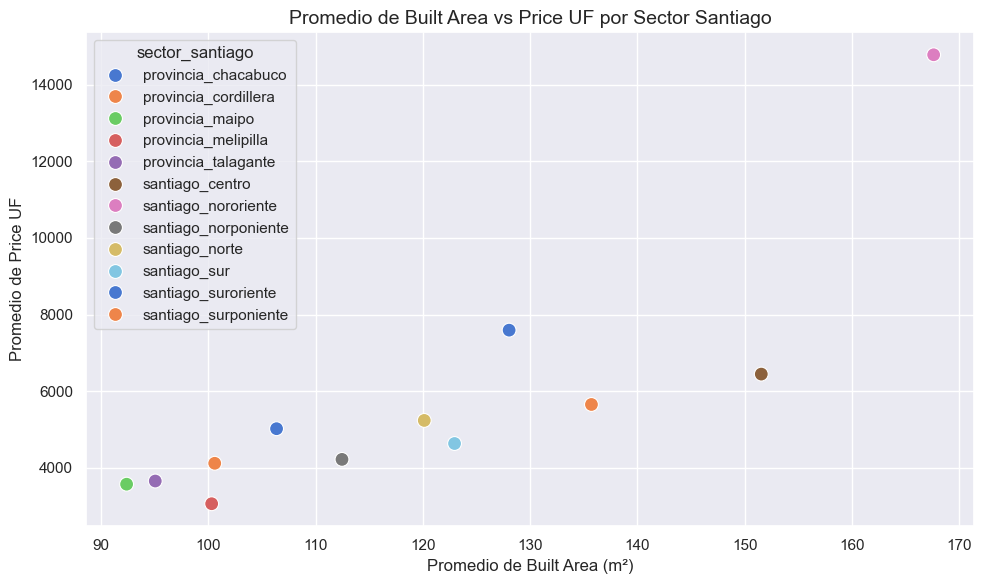

In [89]:
# Calcular el promedio de 'built_area' y 'price_uf' por 'sector_santiago'
promedio_price_uf_built_area = df_final.groupby('sector_santiago').agg(
    promedio_built_area=('built_area', 'mean'),
    promedio_price_uf=('price_uf', 'mean')
).reset_index()

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='promedio_built_area', y='promedio_price_uf', hue='sector_santiago', data=promedio_price_uf_built_area, palette="muted", s=100)

# Etiquetas del gráfico
plt.title('Promedio de Built Area vs Price UF por Sector Santiago', fontsize=14)
plt.xlabel('Promedio de Built Area (m²)', fontsize=12)
plt.ylabel('Promedio de Price UF', fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


C:\Users\raval\AppData\Local\Temp\ipykernel_10320\1664981217.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


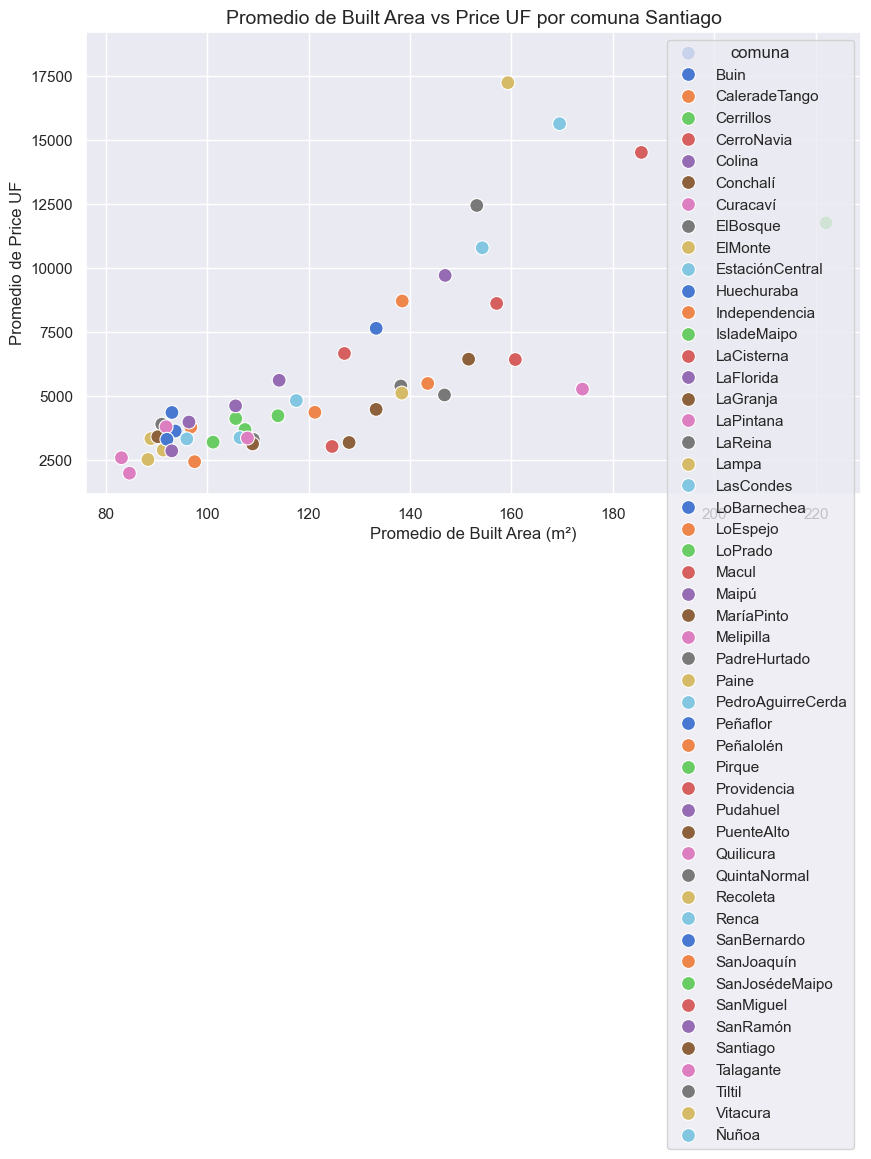

In [169]:
# Calcular el promedio de 'built_area' y 'price_uf' por 'sector_santiago'
promedio_price_uf_built_area = df_final.groupby('comuna').agg(
    promedio_built_area=('built_area', 'mean'),
    promedio_price_uf=('price_uf', 'mean')
).reset_index()

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x='promedio_built_area', y='promedio_price_uf', hue='comuna', data=promedio_price_uf_built_area, palette="muted", s=100)

# Etiquetas del gráfico
plt.title('Promedio de Built Area vs Price UF por comuna Santiago', fontsize=14)
plt.xlabel('Promedio de Built Area (m²)', fontsize=12)
plt.ylabel('Promedio de Price UF', fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


In [90]:
# Calcular el promedio de 'price_uf' y 'built_area' por 'sector_santiago'
promedio_sector = df_final.groupby('sector_santiago').agg(
    promedio_built_area=('built_area', 'mean'),
    promedio_price_uf=('price_uf', 'mean')
).reset_index()

# Calcular el valor del metro cuadrado en UF
promedio_sector['valor_m2_uf'] = promedio_sector['promedio_price_uf'] / promedio_sector['promedio_built_area']

# Mostrar la tabla con los resultados
print(promedio_sector[['sector_santiago', 'promedio_built_area', 'promedio_price_uf', 'valor_m2_uf']])

         sector_santiago  promedio_built_area  promedio_price_uf  valor_m2_uf
0    provincia_chacabuco           128.035425        7593.633603    59.308848
1   provincia_cordillera           135.714286        5655.000000    41.668421
2        provincia_maipo            92.365079        3576.031746    38.716274
3    provincia_melipilla           100.297297        3066.567568    30.574778
4    provincia_talagante            95.037946        3658.741071    38.497687
5        santiago_centro           151.552239        6447.482587    42.542972
6    santiago_nororiente           167.624792       14775.244592    88.144745
7   santiago_norponiente           112.450820        4222.948087    37.553733
8         santiago_norte           120.122768        5238.810268    43.612134
9           santiago_sur           122.947791        4637.036145    37.715490
10   santiago_suroriente           106.349124        5023.194030    47.233055
11  santiago_surponiente           100.582902        4121.344560

In [173]:
# Calcular el promedio de 'price_uf' y 'built_area' por 'sector_santiago'
promedio_sector = df_final.groupby('comuna').agg(
    promedio_built_area=('built_area', 'mean'),
    promedio_price_uf=('price_uf', 'mean')
).reset_index()

# Calcular el valor del metro cuadrado en UF
promedio_sector['valor_m2_uf'] = promedio_sector['promedio_price_uf'] / promedio_sector['promedio_built_area']

# Ordenar la tabla de mayor a menor por 'valor_m2_uf'
promedio_sector = promedio_sector.sort_values(by='valor_m2_uf', ascending=False)

# Mostrar la tabla con los resultados
print(promedio_sector[['comuna', 'promedio_built_area', 'promedio_price_uf', 'valor_m2_uf']])


               comuna  promedio_built_area  promedio_price_uf  valor_m2_uf
48           Vitacura           159.294118       17241.810458   108.238840
20        LoBarnechea           194.868966       18393.103448    94.387033
19          LasCondes           169.484185       15641.021898    92.286026
17            LaReina           153.167568       12447.637838    81.268104
33        Providencia           185.607477       14519.252336    78.225579
49              Ñuñoa           154.243781       10796.089552    69.993678
4              Colina           146.937500        9718.021341    66.137108
31          Peñalolén           138.474790        8717.084034    62.950693
10         Huechuraba           133.339450        7652.422018    57.390533
43          SanMiguel           157.087209        8623.069767    54.893519
42     SanJosédeMaipo           222.000000       11770.500000    53.020270
23              Macul           127.086207        6670.402299    52.487225
14          LaFlorida    

In [175]:
# Calcular el promedio de 'valor_m2_uf' y 'promedio_built_area' de todas las comunas
promedio_valor_m2_uf = promedio_sector['valor_m2_uf'].mean()
promedio_built_area_total = promedio_sector['promedio_built_area'].mean()

print("Promedio del valor por metro cuadrado en UF (valor_m2_uf):", promedio_valor_m2_uf)
print("Promedio del área construida (promedio_built_area):", promedio_built_area_total)


Promedio del valor por metro cuadrado en UF (valor_m2_uf): 44.37552480684131
Promedio del área construida (promedio_built_area): 123.37898028605423


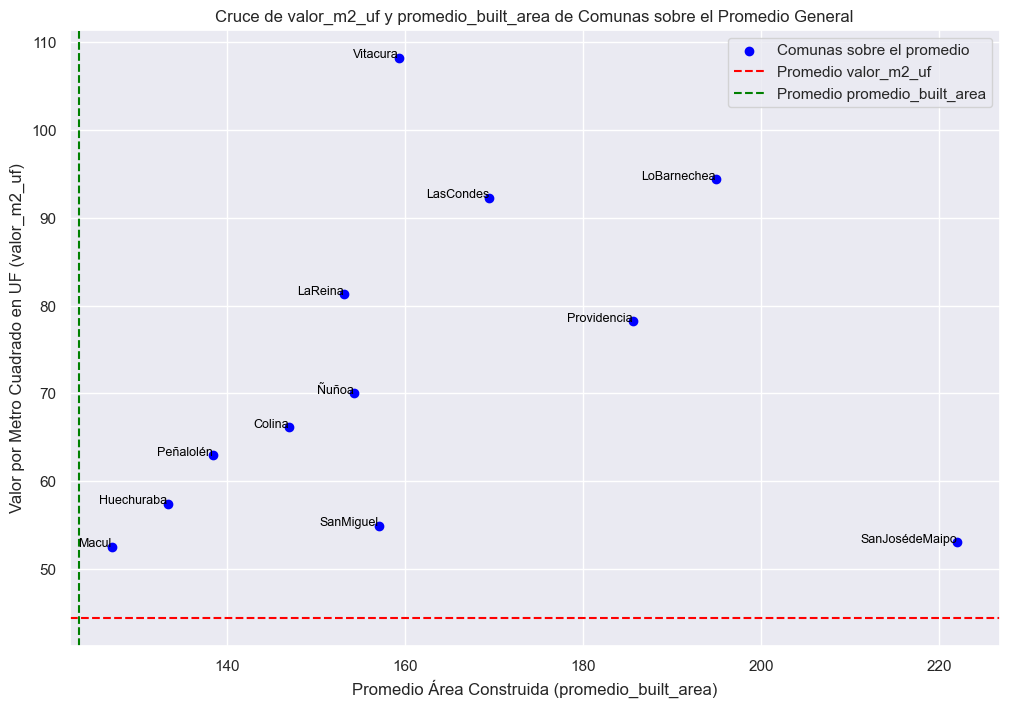

In [181]:
# Calcular los promedios generales
promedio_valor_m2_uf = promedio_sector['valor_m2_uf'].mean()
promedio_built_area_total = promedio_sector['promedio_built_area'].mean()

# Filtrar las comunas que están sobre el promedio en ambas métricas
comunas_sobre_promedio = promedio_sector[
    (promedio_sector['valor_m2_uf'] > promedio_valor_m2_uf) &
    (promedio_sector['promedio_built_area'] > promedio_built_area_total)
]

# Crear el gráfico de dispersión
plt.figure(figsize=(12, 8))
plt.scatter(comunas_sobre_promedio['promedio_built_area'], comunas_sobre_promedio['valor_m2_uf'], color='blue', label='Comunas sobre el promedio')

# Añadir etiquetas de comunas
for i in range(len(comunas_sobre_promedio)):
    plt.text(comunas_sobre_promedio['promedio_built_area'].iloc[i],
             comunas_sobre_promedio['valor_m2_uf'].iloc[i],
             comunas_sobre_promedio['comuna'].iloc[i],
             fontsize=9, ha='right', color='black')

# Líneas de promedio
plt.axhline(promedio_valor_m2_uf, color='red', linestyle='--', label='Promedio valor_m2_uf')
plt.axvline(promedio_built_area_total, color='green', linestyle='--', label='Promedio promedio_built_area')

# Etiquetas y título
plt.xlabel('Promedio Área Construida (promedio_built_area)')
plt.ylabel('Valor por Metro Cuadrado en UF (valor_m2_uf)')
plt.title('Cruce de valor_m2_uf y promedio_built_area de Comunas sobre el Promedio General')
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()


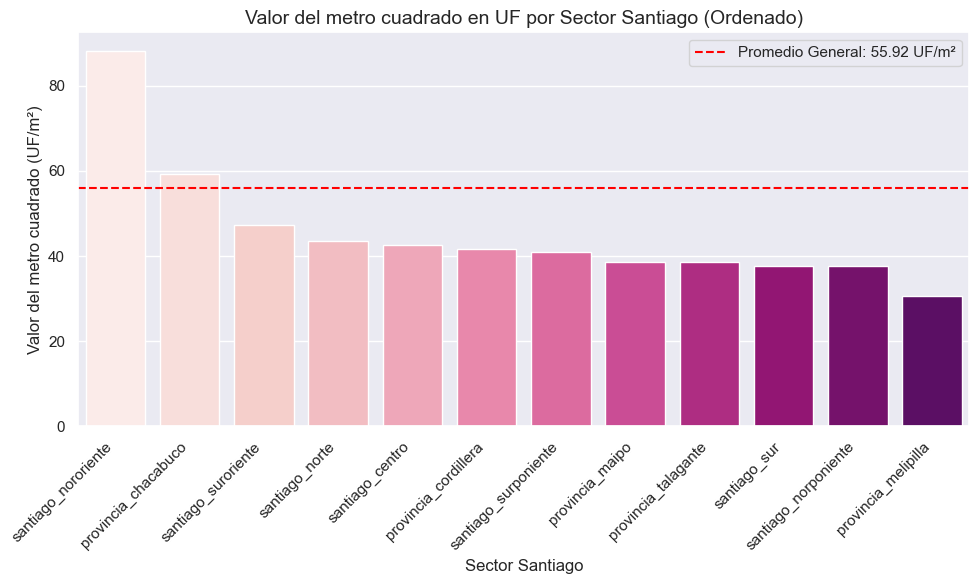

In [91]:
# Calcular el promedio de 'price_uf' y 'built_area' por 'sector_santiago'
promedio_sector = df_final.groupby('sector_santiago').agg(
    promedio_built_area=('built_area', 'mean'),
    promedio_price_uf=('price_uf', 'mean')
).reset_index()

# Calcular el valor del metro cuadrado en UF
promedio_sector['valor_m2_uf'] = promedio_sector['promedio_price_uf'] / promedio_sector['promedio_built_area']

# Calcular el valor promedio del metro cuadrado en UF para todas las comunas
valor_promedio_m2_uf = df_final['price_uf'].mean() / df_final['built_area'].mean()

# Ordenar de mayor a menor el valor del metro cuadrado
promedio_sector = promedio_sector.sort_values(by='valor_m2_uf', ascending=False)

# Crear el histograma
plt.figure(figsize=(10, 6))
sns.barplot(x='sector_santiago', y='valor_m2_uf', data=promedio_sector, hue='sector_santiago', dodge=False, palette='RdPu', legend=False)

# Añadir una línea horizontal con el valor promedio general del metro cuadrado
plt.axhline(valor_promedio_m2_uf, color='red', linestyle='--', label=f'Promedio General: {valor_promedio_m2_uf:.2f} UF/m²')

# Etiquetas del gráfico
plt.title('Valor del metro cuadrado en UF por Sector Santiago (Ordenado)', fontsize=14)
plt.xlabel('Sector Santiago', fontsize=12)
plt.ylabel('Valor del metro cuadrado (UF/m²)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mostrar la leyenda
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [92]:
# Valor de la UF en pesos chilenos hoy
valor_uf_hoy = 37957.96

# Calcular el promedio de 'built_area' y 'price_uf' para todas las propiedades en df3
promedio_built_area_total = df_final['built_area'].mean()
promedio_price_uf_total = df_final['price_uf'].mean()

# Calcular el valor por metro cuadrado en UF
valor_m2_total_uf = promedio_price_uf_total / promedio_built_area_total

# Calcular el valor por metro cuadrado en CLP
valor_m2_total_clp = valor_m2_total_uf * valor_uf_hoy

# Calcular el valor promedio de price_uf en CLP
promedio_price_uf_clp = promedio_price_uf_total * valor_uf_hoy

# Mostrar los resultados
print(f'Promedio de Built Area: {promedio_built_area_total:.2f} m²')
print(f'Promedio de Price UF: {promedio_price_uf_total:.2f} UF')
print(f'Promedio de Price UF en CLP: {promedio_price_uf_clp:,.2f} CLP')
print(f'Valor por metro cuadrado: {valor_m2_total_uf:.2f} UF/m²')
print(f'Valor por metro cuadrado en CLP: {valor_m2_total_clp:,.2f} CLP/m²')

Promedio de Built Area: 121.91 m²
Promedio de Price UF: 6817.67 UF
Promedio de Price UF en CLP: 258,785,011.03 CLP
Valor por metro cuadrado: 55.92 UF/m²
Valor por metro cuadrado en CLP: 2,122,777.52 CLP/m²


In [93]:
# Valor de la UF en pesos chilenos hoy
valor_uf_hoy = 37957.96

# Agrupar por sector_santiago y calcular los promedios
promedios_sector = df_final.groupby('sector_santiago').agg(
    promedio_built_area=('built_area', 'mean'),
    promedio_price_uf=('price_uf', 'mean')
).reset_index()

# Calcular el valor por metro cuadrado en UF y en CLP para cada sector
promedios_sector['valor_m2_total_uf'] = promedios_sector['promedio_price_uf'] / promedios_sector['promedio_built_area']
promedios_sector['valor_m2_total_clp'] = promedios_sector['valor_m2_total_uf'] * valor_uf_hoy
promedios_sector['promedio_price_uf_clp'] = promedios_sector['promedio_price_uf'] * valor_uf_hoy

# Mostrar los resultados
for i, row in promedios_sector.iterrows():
    print(f"Sector: {row['sector_santiago']}")
    print(f'Promedio de Built Area: {row["promedio_built_area"]:.2f} m²')
    print(f'Promedio de Price UF: {row["promedio_price_uf"]:.2f} UF')
    print(f'Promedio de Price UF en CLP: {row["promedio_price_uf_clp"]:,.2f} CLP')
    print(f'Valor por metro cuadrado: {row["valor_m2_total_uf"]:.2f} UF/m²')
    print(f'Valor por metro cuadrado en CLP: {row["valor_m2_total_clp"]:,.2f} CLP/m²')
    print("-" * 50)

Sector: provincia_chacabuco
Promedio de Built Area: 128.04 m²
Promedio de Price UF: 7593.63 UF
Promedio de Price UF en CLP: 288,238,840.57 CLP
Valor por metro cuadrado: 59.31 UF/m²
Valor por metro cuadrado en CLP: 2,251,242.89 CLP/m²
--------------------------------------------------
Sector: provincia_cordillera
Promedio de Built Area: 135.71 m²
Promedio de Price UF: 5655.00 UF
Promedio de Price UF en CLP: 214,652,263.80 CLP
Valor por metro cuadrado: 41.67 UF/m²
Valor por metro cuadrado en CLP: 1,581,648.26 CLP/m²
--------------------------------------------------
Sector: provincia_maipo
Promedio de Built Area: 92.37 m²
Promedio de Price UF: 3576.03 UF
Promedio de Price UF en CLP: 135,738,869.97 CLP
Valor por metro cuadrado: 38.72 UF/m²
Valor por metro cuadrado en CLP: 1,469,590.79 CLP/m²
--------------------------------------------------
Sector: provincia_melipilla
Promedio de Built Area: 100.30 m²
Promedio de Price UF: 3066.57 UF
Promedio de Price UF en CLP: 116,400,649.07 CLP
Valor 

In [94]:
# Ruta donde deseas guardar el archivo Excel
ruta_guardado = r'..\data\Precios_Casas_RM_final_visualizaciones.xlsx'
# Guardar el DataFrame df3 en un archivo Excel
df_final.to_excel(ruta_guardado, index=False)

# Confirmar que el archivo ha sido guardado correctamente
print(f"Archivo guardado en: {ruta_guardado}")

Archivo guardado en: ..\data\Precios_Casas_RM_final_visualizaciones.xlsx


In [95]:
df_final.info

<bound method DataFrame.info of       price_uf             comuna  dorms  baths  built_area  total_area  \
0         2950  PedroAguirreCerda      2      1       112.0       145.0   
1         3600    EstaciónCentral      3      1        59.0       243.0   
2         2107             Colina      3      1       103.0        73.0   
3         1489             Colina      2      1        57.0        67.0   
4         2641    EstaciónCentral      2      1        72.0       131.0   
...        ...                ...    ...    ...         ...         ...   
6226      7000           Santiago      3      3       100.0       149.0   
6227      1967    EstaciónCentral      4      2       121.0       200.0   
6228      2390        SanBernardo      5      1       120.0        76.0   
6229      6800          Peñalolén      4      2       124.0       200.0   
6230      9998          Talagante      5      3       225.0       366.0   

      parking  price_built_m2_uf  price_total_m2_uf       sector_sa